Model Training , data cleaning and exploratory data analysis (EDA)(Ridge, Lasso & ElasticNet Regression)

# Project Workflow — Ridge, Lasso Regression.ipynb (PART1)

This notebook covers **data cleaning and exploratory data analysis (EDA)** for the Algerian Forest Fires dataset, in preparation for later Ridge/Lasso/Elastic Net regression modeling of the Fire Weather Index (FWI).

## Stage 1 — Data Loading & Initial Inspection
1. Import `pandas`, `numpy`, `matplotlib`, `seaborn`.
2. Load the raw CSV `Algerian_forest_fires_dataset_UPDATE.csv` with `header=1` (the true column headers sit on row 2; row 1 is a merged title).
3. Preview the data (`.head()`) and inspect structure/dtypes (`.info()`) — at this stage every column is read in as `str`/`object`, including numeric ones.

## Stage 2 — Data Cleaning
1. **Detect missing values**: `dataset[dataset.isnull().any(axis=1)]` surfaces rows with at least one `NaN` — reveals a stray duplicate-header row (index 122, marking where the Sidi-Bel Abbes region's data begins) and one row with a single missing value (index 167).
2. **Add a `Region` column**: rows before index 122 are labeled `0` (Bejaia), rows from 122 onward are labeled `1` (Sidi-Bel Abbes), since the CSV silently concatenates two regional datasets. Cast this new column to `int`.
3. **Drop incomplete rows**: `df.dropna().reset_index(drop=True)` removes rows with any missing values and renumbers the index cleanly (0, 1, 2, ...).
4. **Remove the leftover duplicate header row** at (post-drop) index 122, then reset the index again.
5. **Clean column names**: strip stray leading/trailing whitespace from column labels (e.g. `" RH"`, `"Rain "`, `"Classes  "`) so columns can be referenced reliably.
6. **Fix data types**:
   - Cast `day`, `month`, `year`, `Temperature`, `RH`, `Ws` to `int` (whole-number weather fields).
   - Identify remaining `object`-typed columns via a list comprehension (`dtypes=='O'`), then cast all of them except `Classes` to `float` (FFMC, DMC, DC, ISI, BUI, FWI, Rain) — `Classes` stays as text since it's the categorical fire/not-fire label.
7. **Verify cleaning**: re-run `.info()`, `.isnull().sum()`, and `.describe()` to confirm zero nulls and sensible numeric ranges.
8. **Persist the cleaned dataset**: `df.to_csv('Algerian_forest_fires_cleaned_dataset.csv', index=False)` for reuse by later modeling work.

## Stage 3 — Exploratory Data Analysis (EDA)
1. Create `df_copy` by dropping `day`, `month`, `year` (not needed for correlation analysis).
2. Check class balance via `value_counts()` on `Classes` (`fire` vs `not fire`).
3. **Encode `Classes` to binary**: `np.where(df_copy['Classes'].str.contains('not fire'), 0, 1)` → `0` = not fire, `1` = fire.
4. **Visualize distributions**: histograms (`df_copy.hist(bins=50, figsize=(20,15))`) for every numeric feature, and a pie chart of the fire/not-fire class split.
5. **Correlation analysis**: compute `df_copy.corr()` and visualize it with `sns.heatmap(...)` to spot multicollinearity between features (e.g. DMC/DC/BUI/FWI are all highly correlated, as expected from the FWI system's internal formulas).
6. **Outlier/skew inspection**: boxplot of `FWI` reveals a right-skewed distribution — most days have low-to-moderate fire risk, with a long tail of rare high-FWI days.
7. **Seasonal fire trends**: after temporarily restoring text labels for `Classes`, count-plot fires per month for each region (Sidi-Bel Abbes and Bejaia) to observe that August sees the most fires across both regions. *(Note: both region-specific plots currently pass `data=df` instead of their filtered `data=dftemp`, so they render identical combined-region data rather than two distinct region breakdowns — a bug worth fixing if per-region comparison is needed.)*

## Summary of This Notebook's Pipeline
```
Raw CSV → detect & drop missing rows → add Region column → remove duplicate header row
        → clean column names → fix data types → verify cleanliness
        → save cleaned CSV → EDA (distributions, correlation, skew, seasonality)
```

The cleaned dataset produced here (`Algerian_forest_fires_cleaned_dataset.csv`) is the handoff point for any subsequent modeling work, so that cleaning logic isn't duplicated or re-run unnecessarily.

PART ONE

## Algerian Forest Fires Dataset
Data Set Information:

The dataset includes 244 instances that regroup a data of two regions of Algeria,namely the Bejaia region located in the northeast of Algeria and the Sidi Bel-abbes region located in the northwest of Algeria.

122 instances for each region.

The period from June 2012 to September 2012.
The dataset includes 11 attribues and 1 output attribue (class)
The 244 instances have been classified into fire(138 classes) and not fire (106 classes) classes.

Attribute Information:

1. Date : (DD/MM/YYYY) Day, month ('june' to 'september'), year (2012)
Weather data observations
2. Temp : temperature noon (temperature max) in Celsius degrees: 22 to 42
3. RH : Relative Humidity in %: 21 to 90
4. Ws :Wind speed in km/h: 6 to 29
5. Rain: total day in mm: 0 to 16.8
FWI Components
6. Fine Fuel Moisture Code (FFMC) index from the FWI system: 28.6 to 92.5
7. Duff Moisture Code (DMC) index from the FWI system: 1.1 to 65.9
8. Drought Code (DC) index from the FWI system: 7 to 220.4
9. Initial Spread Index (ISI) index from the FWI system: 0 to 18.5
10. Buildup Index (BUI) index from the FWI system: 1.1 to 68
11. Fire Weather Index (FWI) Index: 0 to 31.1
12. Classes: two classes, namely Fire and not Fire

### Import Required Libraries
Import `pandas` and `numpy` for data manipulation, `matplotlib.pyplot` and `seaborn` for visualization, and enable inline plotting with `%matplotlib inline`.

In [185]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Load the Raw Dataset
Read the raw `Algerian_forest_fires_dataset_UPDATE.csv` file into a pandas DataFrame. `header=1` is used because the actual column headers sit on the second row of the CSV (the first row is a merged title row).

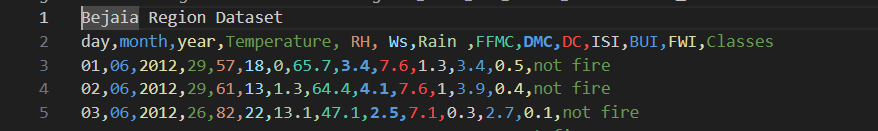

In [186]:
dataset=pd.read_csv('Algerian_forest_fires_dataset_UPDATE.csv' ,header=1)

### Preview the Dataset
Display the first 5 rows of the raw dataset to get an initial look at its structure and values.

In [187]:
dataset.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


### Inspect Dataset Structure
Display column names, data types, and non-null counts to understand the dataset before cleaning it.

In [188]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
dtypes: object(14)
memory usage: 27.0+ KB


## Data Cleaning

### Check for Missing Values
Filter and display all columns that contain at least one missing (NaN) value, to identify where cleaning is needed.

In [189]:
dataset.isnull().sum()

,0
day,0
month,1
year,1
Temperature,1
RH,1
Ws,1
Rain,1
FFMC,1
DMC,1
DC,1


### Check for Missing Values
Filter and display all rows that contain at least one missing (NaN) value, to identify where cleaning is needed.

In [190]:
dataset.isnull().any(axis=1)

,0
0,False
1,False
2,False
3,False
4,False
...,...
241,False
242,False
243,False
244,False


**Detailed explanation of `dataset[dataset.isnull().any(axis=1)]`:**

1. **`dataset.isnull()`** — Returns a new DataFrame of the same shape as `dataset`, but filled with boolean values: `True` wherever the original had a missing value (`NaN`/`None`/`NaT`), `False` everywhere else.

2. **`.any(axis=1)`** — Collapses that boolean DataFrame down to a single boolean Series, one value per row:
   - `axis=1` means "check across the columns, for each row" (as opposed to `axis=0`, which checks down each column across all rows).
   - `.any(...)` returns `True` for a row if **at least one** value in that row is `True` (i.e., at least one column has a missing value in that row), and `False` only if the entire row has no missing values.

3. **`dataset[...]`** — This is boolean indexing: passing a boolean Series into `dataset[...]` filters the DataFrame to keep only the rows where the Series is `True`. So this returns a new DataFrame containing **only the rows that have at least one missing value anywhere in them**.

**Purpose:** this one-liner answers "which rows have any missing data?" — a diagnostic step used to inspect problematic rows before deciding how to clean them.

**Example:**
```python
import pandas as pd
df = pd.DataFrame({'A': [1, None, 3], 'B': [4, 5, None]})
df[df.isnull().any(axis=1)]
#      A    B
# 1  NaN  5.0
# 2  3.0  NaN
```
Row 0 is excluded since it has no missing values; rows 1 and 2 are included because each has at least one `NaN`.

**In this notebook:** this line surfaces rows 122 (a stray duplicate region-header row with almost all values `NaN`) and 167 (a row with one missing value) — exactly why the later cleaning steps (`dropna()`, dropping row 122) were needed.

In [191]:
## missing values
dataset[dataset.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


The dataset is converted into two sets based on Region from 122th index, we can make a new column based on the Region

1 : "Bejaia Region Dataset"

2 : "Sidi-Bel Abbes Region Dataset"

Add new column with region

### Create a Region Column
Add a new `Region` column to distinguish the two regions in the dataset: rows up to index 122 belong to the Bejaia region (labeled 0) and rows from index 122 onward belong to the Sidi-Bel Abbes region (labeled 1). The result is reassigned to `df` for further processing.

In [192]:
dataset.loc[:122,"Region"]=0
dataset.loc[122:,"Region"]=1
df=dataset

### Verify Structure After Adding Region
Check the DataFrame's structure again to confirm the new `Region` column was added correctly.

In [193]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          246 non-null    object 
 1   month        245 non-null    object 
 2   year         245 non-null    object 
 3   Temperature  245 non-null    object 
 4    RH          245 non-null    object 
 5    Ws          245 non-null    object 
 6   Rain         245 non-null    object 
 7   FFMC         245 non-null    object 
 8   DMC          245 non-null    object 
 9   DC           245 non-null    object 
 10  ISI          245 non-null    object 
 11  BUI          245 non-null    object 
 12  FWI          245 non-null    object 
 13  Classes      244 non-null    object 
 14  Region       246 non-null    float64
dtypes: float64(1), object(14)
memory usage: 29.0+ KB


### Convert Region to Integer Type
Cast the `Region` column to integer type since it was created as a float during assignment.

In [194]:
df[['Region']]=df[['Region']].astype(int)

### Preview Updated Dataset
Display the first 5 rows to confirm the `Region` column was added correctly.

In [195]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [196]:
df

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,26,09,2012,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,fire,1
242,27,09,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,not fire,1
243,28,09,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,not fire,1
244,29,09,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,not fire,1


### Count Missing Values Per Column
Count the number of missing (NaN) values in each column to quantify how much cleaning is required.

In [197]:
df.isnull().sum()

,0
day,0
month,1
year,1
Temperature,1
RH,1
Ws,1
Rain,1
FFMC,1
DMC,1
DC,1


### Remove Rows with Missing Values
Drop all rows containing any null values and reset the DataFrame index so it stays continuous (0, 1, 2, ...).

**Detailed explanation of `df=df.dropna().reset_index(drop=True)`:**

1. **`df.dropna()`** — Scans the DataFrame for missing values (`NaN`, `None`, `NaT`). By default (`axis=0`, `how='any'`), it drops any **row** that contains at least one missing value and returns a new DataFrame. The original index labels of the surviving rows are kept as-is, so gaps appear where rows were removed (e.g. 0, 1, 3, 4, 6...).

2. **`.reset_index(drop=True)`** — Chained on the result above. Since dropping rows leaves gaps in the index, this regenerates a clean, sequential index (0, 1, 2, 3...). The `drop=True` argument tells pandas to discard the old index entirely instead of inserting it back as a new `"index"` column (which is the default behavior of `reset_index()` without this argument).

3. **`df = ...`** — Both `dropna()` and `reset_index()` return new DataFrames rather than modifying in place. Reassigning to `df` overwrites the original variable with the cleaned, re-indexed version.

**Net effect:** `df` now contains only complete rows (no missing values) with a fresh 0-based sequential index and no leftover index column.

**Example:**
```python
import pandas as pd
df = pd.DataFrame({'A': [1, None, 3, 4], 'B': [5, 6, None, 8]})
df = df.dropna().reset_index(drop=True)
# Rows with NaN (index 1, 2) are removed; remaining rows are renumbered 0, 1
```

**Why it matters here:** scikit-learn's Ridge, Lasso, and Elastic Net models cannot handle `NaN` values during `.fit()`, so removing incomplete rows is a required preprocessing step before training.

**Note on `axis`:** `dropna()` defaults to `axis=0` (drop rows). Passing `axis=1` instead would drop **columns** containing any NaN — used when a whole feature is unreliable, not when cleaning bad observations. For this dataset, `axis=0` is correct since the goal is to remove incomplete rows, not features.

**A closer look at the `drop=True` parameter in `reset_index()`:**

`drop=True` controls whether the *old* index is kept as a new column or thrown away when the index is reset.

- **`reset_index()`** (default, `drop=False`) — Resets the index to a fresh 0-based sequence, but **preserves** the old index values by inserting them as a new column named `"index"` (or the index's name, if it had one):
  ```python
  df.reset_index()
  #    index    A
  # 0    3      1
  # 1    5      2
  ```

- **`reset_index(drop=True)`** — Resets the index the same way, but **discards** the old index entirely instead of turning it into a column:
  ```python
  df.reset_index(drop=True)
  #    A
  # 0  1
  # 1  2
  ```

**Why it matters here:** after `df.dropna()` removes rows, the remaining rows keep their original (now-gapped) index labels. `reset_index(drop=True)` renumbers them cleanly to `0, 1, 2, ...` without polluting the DataFrame with a leftover `"index"` column that isn't needed, since the old index wasn't meaningful data to begin with — just a row position.

**Rule of thumb:** use `drop=True` whenever the existing index is just a positional counter you don't need to keep; omit it (or use `drop=False`) only if the old index held meaningful information you want to retain as a column.

In [198]:
## Removing the null values
df=df.dropna().reset_index(drop=True)

### Preview Dataset After Dropping Nulls
Display the first 5 rows to confirm the cleaning step was applied.

In [199]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


### Re-verify No Missing Values Remain
Confirm that the null-value count for every column is now zero after dropping the missing rows.

In [200]:
df.isnull().sum()

,0
day,0
month,0
year,0
Temperature,0
RH,0
Ws,0
Rain,0
FFMC,0
DMC,0
DC,0


In [201]:
df.head(125
        )

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,29,09,2012,26,80,16,1.8,47.4,2.9,7.7,0.3,3,0.1,not fire,0
121,30,09,2012,25,78,14,1.4,45,1.9,7.5,0.2,2.4,0.1,not fire,0
122,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,1
123,01,06,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire,1


### Inspect Row 122
Display the row at index 122 to check the boundary between the two regions, since a duplicate header row is expected to sit at this position after combining the two regions' data.

In [202]:
df.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,1


### Remove the Duplicate Header Row
Drop the row at index 122, which contains a redundant header left over from combining the two regions, and reset the index.

In [203]:
##remove the 122nd row
df=df.drop(122).reset_index(drop=True)

### Verify the Row Was Removed
Display row 122 again to confirm it now holds actual data instead of the duplicate header.

In [204]:
df.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,01,06,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire,1


### List Column Names
Print all column names to check for inconsistencies such as extra whitespace.

In [205]:
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='object')

### Clean Column Name Whitespace
Strip leading/trailing spaces from all column names to avoid errors when referencing columns later.

In [206]:
## fix spaces in columns names
df.columns=df.columns.str.strip()
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

### Check Data Types After Column Cleanup
Inspect the DataFrame's structure again after fixing the column names.

In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          243 non-null    object
 1   month        243 non-null    object
 2   year         243 non-null    object
 3   Temperature  243 non-null    object
 4   RH           243 non-null    object
 5   Ws           243 non-null    object
 6   Rain         243 non-null    object
 7   FFMC         243 non-null    object
 8   DMC          243 non-null    object
 9   DC           243 non-null    object
 10  ISI          243 non-null    object
 11  BUI          243 non-null    object
 12  FWI          243 non-null    object
 13  Classes      243 non-null    object
 14  Region       243 non-null    int64 
dtypes: int64(1), object(14)
memory usage: 28.6+ KB


#### Changes the required columns as integer data type

### Review Column Names Before Type Conversion
List the columns again to identify which ones should be converted to integer type.

In [208]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

### Convert Selected Columns to Integer
Cast the `month`, `day`, `year`, `Temperature`, `RH`, and `Ws` columns to integer type, since they represent whole-number values but were read in as strings/objects.

In [209]:
df[['month','day','year','Temperature','RH','Ws']]=df[['month','day','year','Temperature','RH','Ws']].astype(int)

### Confirm Integer Conversion
Check data types again to confirm the selected columns are now integers.

In [210]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          243 non-null    int64 
 1   month        243 non-null    int64 
 2   year         243 non-null    int64 
 3   Temperature  243 non-null    int64 
 4   RH           243 non-null    int64 
 5   Ws           243 non-null    int64 
 6   Rain         243 non-null    object
 7   FFMC         243 non-null    object
 8   DMC          243 non-null    object
 9   DC           243 non-null    object
 10  ISI          243 non-null    object
 11  BUI          243 non-null    object
 12  FWI          243 non-null    object
 13  Classes      243 non-null    object
 14  Region       243 non-null    int64 
dtypes: int64(7), object(8)
memory usage: 28.6+ KB


#### Changing the other columns to float data datatype


**Detailed explanation of `objects=[features for features in df.columns if df[features].dtypes=='O']`:**

This is a **list comprehension** — a compact way to build a list by looping and filtering in one line. Written as an explicit loop, it's equivalent to:

```python
objects = []
for features in df.columns:
    if df[features].dtypes == 'O':
        objects.append(features)
```

**Piece by piece:**

1. **`df.columns`** — Returns an `Index` object containing all column names of the DataFrame (e.g. `['day', 'month', 'Rain', 'Classes', ...]`).

2. **`for features in df.columns`** — Iterates over each column name one at a time, temporarily naming it `features` on each pass.

3. **`df[features]`** — Selects that one column as a pandas `Series` (e.g. `df['Rain']`).

4. **`.dtypes`** — Returns the data type of that Series (e.g. `dtype('int64')`, `dtype('float64')`, or `dtype('O')`).

5. **`== 'O'`** — Checks whether the dtype is `object`. In pandas, `'O'` is shorthand for the `object` dtype, which is what pandas uses to store **strings** (and mixed/non-numeric data). So this condition is true only for columns pandas still thinks contain text.

6. **`[features for ... if ...]`** — Only column names that pass the `dtypes=='O'` check are collected into the resulting list.

7. **`objects = ...`** — The final list of column names is stored in the variable `objects`.

**In context of this notebook:** at this point, columns like `day`, `month`, `year`, `Temperature`, `RH`, `Ws` were already cast to `int` in an earlier cell, but columns like `Rain`, `FFMC`, `DMC`, `DC`, `ISI`, `BUI`, `FWI`, and `Classes` are still stored as strings (leftover from reading the CSV). So `objects` ends up being something like:

```python
['Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes']
```

This list is then used in the next cell to loop through and convert everything except `Classes` to `float`, since `Classes` is meant to stay as a categorical text label (`fire` / `not fire`) rather than become numeric.

**Why check `=='O'` instead of just converting all columns?** Because blindly casting every column to float would break `Classes`, which holds text, not numbers — so this step first identifies *which* columns still need numeric conversion.

### Identify Remaining Object-Type Columns
Build a list of columns that still have an `object` (string) data type, which need to be converted to numeric types.

In [211]:
objects=[features for features in df.columns if df[features].dtypes=='O']

### Convert Remaining Columns to Float
Loop through the identified object columns and convert each one to float type, except for the `Classes` column, which should stay categorical (text).

In [212]:
for i in objects:
    if i!='Classes':
        df[i]=df[i].astype(float)

### Verify Final Data Types
Check the DataFrame's structure once more to confirm all feature columns are now numeric except `Classes`.

In [213]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    int64  
dtypes: float64(7), int64(7), object(1)
memory usage: 28.6+ KB


### Recheck Object Columns
List the object-type columns again; only `Classes` should remain, confirming the conversion loop worked correctly.

In [214]:
objects

['Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes']

### Generate Summary Statistics
Display descriptive statistics (mean, std, min, max, quartiles) for all numeric columns to understand the data distribution and spot outliers.

In [215]:
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,243.000000,243.000000,243.0,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,15.761317,7.502058,2012.0,32.152263,62.041152,15.493827,0.762963,77.842387,14.680658,49.430864,4.742387,16.690535,7.035391,0.497942
std,8.842552,1.114793,0.0,3.628039,14.828160,2.811385,2.003207,14.349641,12.393040,47.665606,4.154234,14.228421,7.440568,0.501028
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.500000,14.000000,0.000000,71.850000,5.800000,12.350000,1.400000,6.000000,0.700000,0.000000
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.300000,11.300000,33.100000,3.500000,12.400000,4.200000,0.000000
75%,23.000000,8.000000,2012.0,35.000000,73.500000,17.000000,0.500000,88.300000,20.800000,69.100000,7.250000,22.650000,11.450000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


### Preview Fully Cleaned Dataset
Display the first 5 rows of the cleaned dataset before saving it to disk.

In [216]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


### Save the Cleaned Dataset
Export the cleaned DataFrame to a new CSV file, `Algerian_forest_fires_cleaned_dataset.csv`, so it can be reused directly in the model training notebook without repeating the cleaning steps.

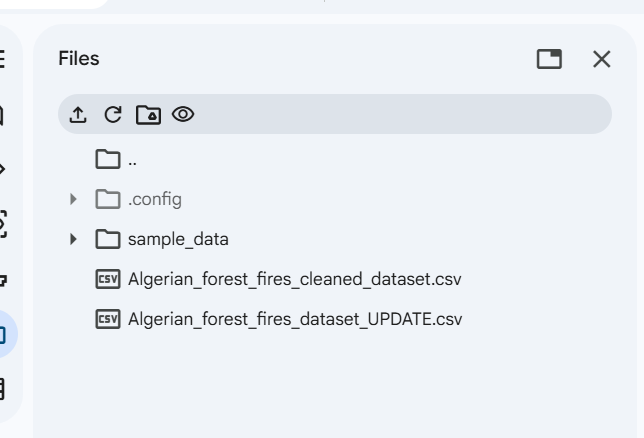

In [217]:
## Let ave the cleaned dataset
df.to_csv('Algerian_forest_fires_cleaned_dataset.csv',index=False)

##  Exploratory Data Analysis

### Drop Date-Related Columns
Create a copy of the cleaned dataset (`df_copy`) with the `day`, `month`, and `year` columns removed, since they are not needed for the exploratory analysis and modeling that follows.

In [218]:
## drop day,month and year
df_copy=df.drop(['day','month','year'],axis=1)

### Preview the Reduced Dataset
Display the first 5 rows of `df_copy` to confirm the date columns were dropped.

In [219]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


### Check Class Distribution
Count how many rows fall into each category of the `Classes` column (`fire` vs `not fire`) to check for class imbalance.

In [220]:
## categories in classes
df_copy['Classes'].value_counts()

,count
Classes,
fire,131
not fire,101
fire,4
fire,2
not fire,2
not fire,1
not fire,1
not fire,1


### Encode the Target Classes as Binary
Convert the categorical `Classes` column into binary numeric values: 0 for `not fire` and 1 for `fire`, using `np.where`.

**Detailed explanation of `df_copy['Classes']=np.where(df_copy['Classes'].str.contains('not fire'),0,1)`:**

**Overall purpose:** Convert the `Classes` column from text labels (`'fire'`, `'not fire'`) into binary numeric values (0/1), which is required because machine learning models (Ridge/Lasso/Elastic Net) can only work with numeric data.

**Piece by piece, evaluated inside-out:**

1. **`df_copy['Classes']`** — Selects the `Classes` column as a pandas Series. At this point it contains text values like `'fire'`, `'not fire'` (and possibly messy variants with trailing whitespace, as seen earlier in the `value_counts()` output).

2. **`.str.contains('not fire')`** — The `.str` accessor lets you apply string operations element-wise across the whole Series. `.contains('not fire')` checks each value and returns `True` if the substring `'not fire'` appears anywhere in it, `False` otherwise. This produces a boolean Series, e.g.:
   ```
   0     True   (value was 'not fire')
   1     True
   2    False   (value was 'fire')
   ...
   ```
   Using `.contains()` rather than `==` is more forgiving of extra whitespace or minor formatting inconsistencies in the raw strings, since it matches on substring rather than exact equality.

3. **`np.where(condition, x, y)`** — A vectorized ternary/if-else from NumPy. For each position, it returns `x` if the corresponding value in `condition` is `True`, otherwise `y`. Here:
   - `condition` = the boolean Series from step 2
   - `x = 0` → used when the string contains `'not fire'`
   - `y = 1` → used otherwise (i.e., when it's `'fire'`)

   So the result is a NumPy array of 0s and 1s: `0` for "not fire" rows, `1` for "fire" rows.

4. **`df_copy['Classes'] = ...`** — Assigns the resulting array back into the `Classes` column, overwriting the original text values with the encoded 0/1 values.

**Net effect:** `Classes` becomes numeric where `0` = not fire, `1` = fire.

**Example:**
```python
import pandas as pd, numpy as np
df_copy = pd.DataFrame({'Classes': ['fire', 'not fire', 'fire', 'not fire  ']})
df_copy['Classes'] = np.where(df_copy['Classes'].str.contains('not fire'), 0, 1)
# Classes
# 0    1
# 1    0
# 2    1
# 3    0
```

**Important observation — `'fire'` is never explicitly checked:** The code only tests `.str.contains('not fire')`. Since every value in the column is either `'fire'` or `'not fire'` (a binary category), `np.where` only needs one explicit condition:
- If the string **contains `'not fire'`** → assign `0`
- **Otherwise** (the implicit "else" branch) → assign `1`

So `'fire'` is never matched directly — it's simply whatever falls into the `y` (else) argument of `np.where(condition, x, y)` by failing the `'not fire'` condition. This works cleanly here because there are only two possible categories, but it is a bit fragile: if an unexpected value (a typo, extra category, or `NaN`) ever appeared in `Classes`, it would silently be labeled `1` (fire) since it fails the `'not fire'` check, rather than raising an error or being flagged.

**Why this matters for the pipeline:** this is a manual form of binary encoding (similar in effect to `LabelEncoder` or a boolean cast), turning a categorical target/feature into something regression models can consume numerically.

In [221]:
## Encoding of the categories in classes
df_copy['Classes']=np.where(df_copy['Classes'].str.contains('not fire'),0,1)

### Preview Encoded Dataset
Display the first 5 rows to confirm the `Classes` column has been encoded as 0/1.

In [222]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


### Preview the End of the Dataset
Display the last 5 rows to verify the encoding was applied consistently across the whole dataset.

In [223]:
df_copy.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1
242,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0,1


### Recheck Class Distribution After Encoding
Count the occurrences of each encoded class (0 and 1) to confirm they match the earlier category counts.

In [224]:
df_copy['Classes'].value_counts()

,count
Classes,
1,137
0,106


### Plot Feature Distributions
Plot a histogram (density plot) for every numeric feature to visualize how each variable is distributed across the dataset.

```python
## Plot desnity plot for all features
plt.style.use('seaborn-v0_8' if 'seaborn-v0_8' in plt.style.available else 'seaborn')
df_copy.hist(bins=50,figsize=(20,15))
plt.show()
```

1. **`## Plot desnity plot for all features`** — A comment (typo: "desnity" → "density"). Not executed.

2. **`plt.style.use('seaborn-v0_8' if 'seaborn-v0_8' in plt.style.available else 'seaborn')`** — Picks a matplotlib style sheet with a version-compatible fallback:
   - **`plt.style.available`** — List of all built-in style names available in the current matplotlib installation (e.g. `'ggplot'`, `'seaborn-v0_8'`, `'dark_background'`).
   - **`'seaborn-v0_8' in plt.style.available`** — Checks whether the newer style name exists. In matplotlib ≥3.6, the old seaborn-flavored style names (e.g. `'seaborn'`, `'seaborn-darkgrid'`) were renamed with a `-v0_8` suffix for versioning, while older matplotlib installs only have the plain `'seaborn'` name.
   - **`X if condition else Y`** — Python's ternary conditional expression: evaluates to `'seaborn-v0_8'` if that style exists, otherwise falls back to `'seaborn'`.
   - **`plt.style.use(...)`** — Applies the chosen style globally to all subsequent plots (background grid, colors, fonts, etc.).
   
   This is defensive code so the notebook doesn't crash with a `KeyError`/`OSError` regardless of which matplotlib version is installed.

3. **`df_copy.hist(bins=50,figsize=(20,15))`**
   - **`df_copy.hist(...)`** — A pandas DataFrame method that automatically generates a **histogram** for every numeric column in `df_copy` (Temperature, RH, Ws, Rain, FFMC, DMC, DC, ISI, BUI, FWI, Classes, Region), laid out as a grid of subplots — one per column.
   - **`bins=50`** — Divides each column's value range into 50 equal-width bins and counts how many rows fall into each bin. More bins reveal finer detail in the distribution shape.
   - **`figsize=(20,15)`** — Sets the overall figure size to 20×15 inches so all subplots remain readable given the number of columns.

4. **`plt.show()`** — Renders and displays the figure(s) in the notebook output. With `%matplotlib inline` already set earlier in the notebook, this is largely automatic in Jupyter, but calling it explicitly avoids any leftover `<Figure size...>` text output.

**Note — histogram vs. true density plot:** Despite the comment saying "density plot," this code produces **histograms** (raw frequency counts per bin), not true density plots. A real density plot would normalize the area under each histogram to 1 (`density=True`) or use a smoothed KDE curve (e.g. `df_copy.plot(kind='density')` or `sns.kdeplot`). The comment is slightly misleading — the code visualizes feature distributions via histograms.

**Purpose in the workflow:** This is exploratory data analysis (EDA) — visually inspecting how each feature is distributed (skewed, normal-ish, bimodal, etc.) before scaling and

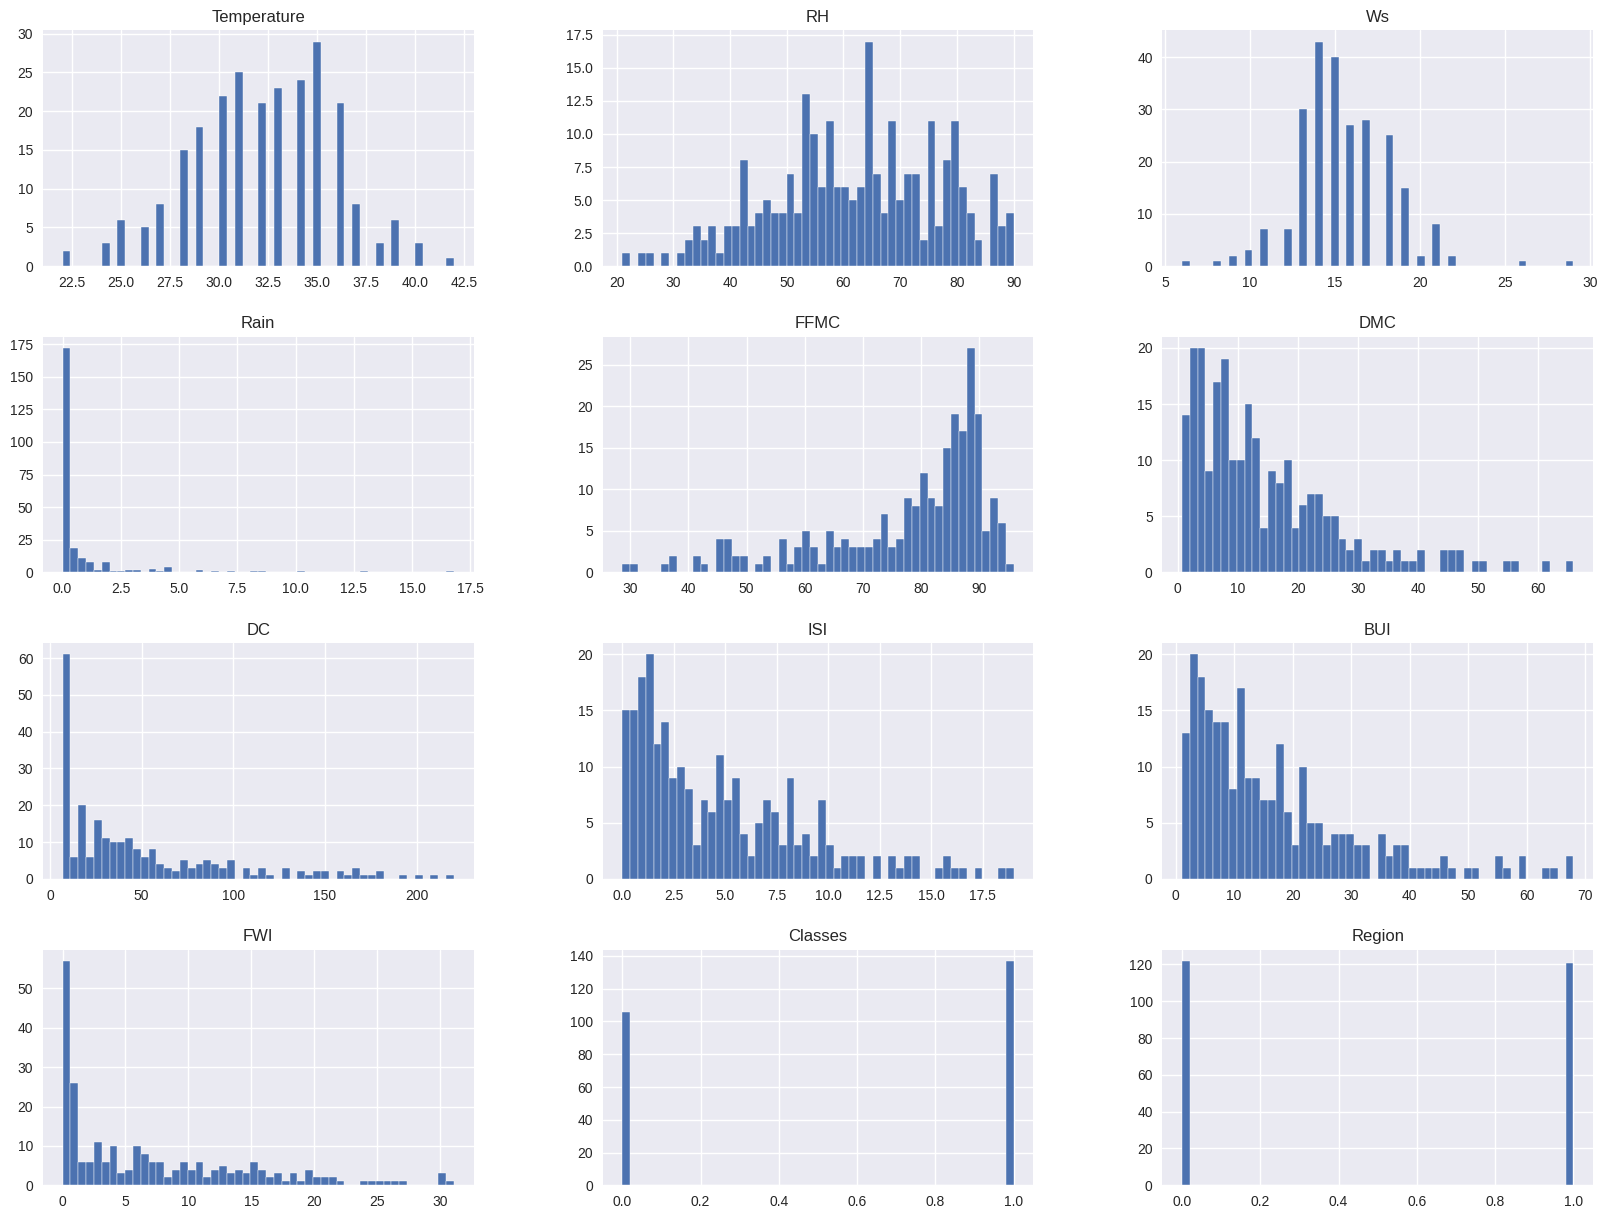

In [225]:
## Plot desnity plot for all features
plt.style.use('seaborn-v0_8' if 'seaborn-v0_8' in plt.style.available else 'seaborn')
df_copy.hist(bins=50,figsize=(20,15))
plt.show()

### Compute Class Percentages
Calculate the percentage share of each class (`fire`/`not fire`) in the dataset, to be used for the pie chart visualization.

With normalize=True, instead of raw counts, it returns each value's proportion (relative frequency) out of the total, so the results sum to 1.0:


df_copy['Classes'].value_counts(normalize=True)
# 1 ->         0.563786
# 0 _>        0.436214

In [226]:
## Percentage for Pie Chart
percentage=df_copy['Classes'].value_counts(normalize=True)*100

### Visualize Class Balance with a Pie Chart
Plot a pie chart showing the proportion of fire vs. not-fire instances in the dataset.

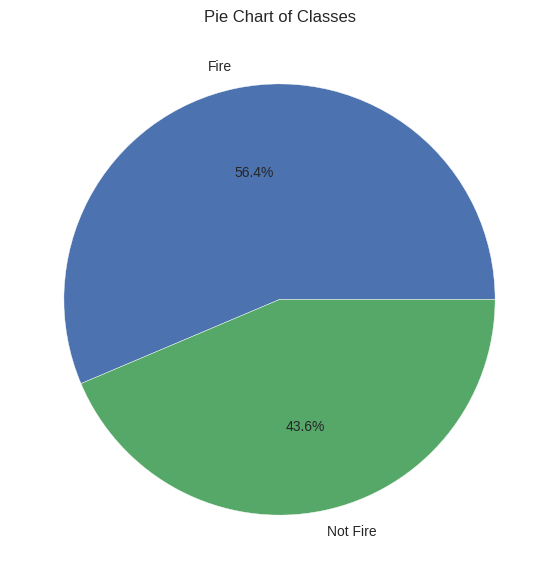

In [227]:
# plotting piechart
classlabels=["Fire","Not Fire"]
plt.figure(figsize=(12,7))
plt.pie(percentage,labels=classlabels,autopct='%1.1f%%')
plt.title("Pie Chart of Classes")
plt.show()

### Correlation Analysis
Section marker cell introducing the correlation analysis between numeric features.

In [228]:
## Correlation

### Compute Correlation Matrix
Calculate pairwise Pearson correlation coefficients between all numeric features in `df_copy`.

In [229]:
df_copy.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102


### Visualize Correlation Heatmap
Plot a heatmap of the correlation matrix to visually identify strongly correlated (and potentially redundant) features.

<Axes: >

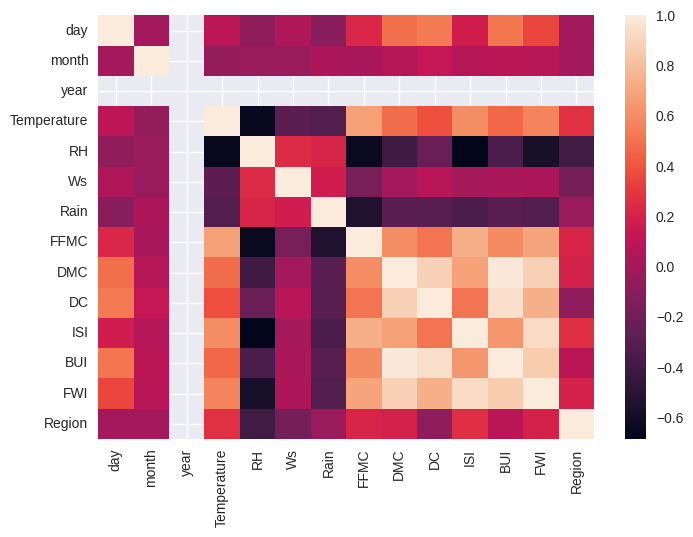

In [230]:
sns.heatmap(df.corr(numeric_only=True))

annot=True — Writes the numeric correlation value in each cell.
fmt='.2f' — Formats the annotation text to 2 decimal places (without this, it may show in scientific notation or too many digits, since the default format is '.2g').

cmap='coolwarm' — A diverging colormap (blue↔red) that visually distinguishes negative vs. positive correlations, which is more intuitive for correlation matrices than the default colormap.

linewidths=0.5 — Adds thin borders between cells so they're visually separated, improving readability with many features.

<Axes: >

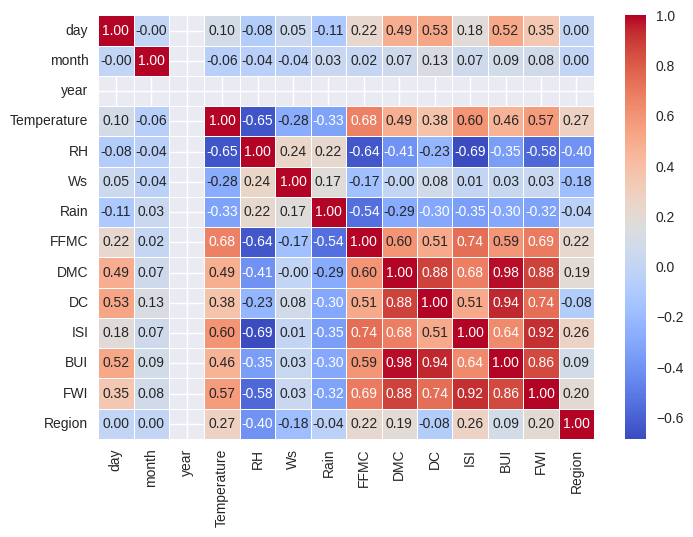

In [232]:
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)


### Boxplot of the FWI Feature
Plot a boxplot of the Fire Weather Index (FWI) column to inspect its spread and detect outliers.

<Axes: ylabel='FWI'>

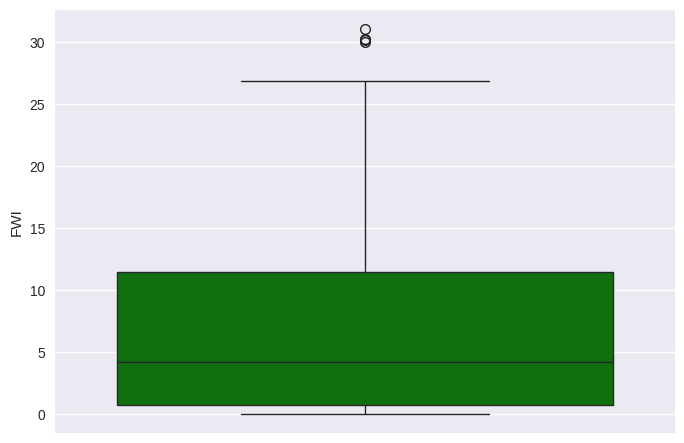

In [233]:
## Box Plots
sns.boxplot(df['FWI'],color='green')

**Interpreting the FWI boxplot — right-skewed distribution:**

The boxplot shows several signs that the `FWI` (Fire Weather Index) values are **right-skewed (positively skewed)**:

- **Median position**: the median line sits closer to the bottom of the box (Q1) than the top (Q3), meaning the lower half of the data (below the median) is compressed into a smaller range than the upper half.
- **Whisker asymmetry**: the upper whisker (toward higher FWI values) extends much farther than the lower whisker, which sits near/at 0.
- **Outliers**: outlier points (diamond markers) appear beyond the upper whisker only, not the lower one, indicating a small number of unusually high FWI days pulling the distribution's tail upward.

Together, these indicate that most FWI values are low-to-moderate, with a long tail of rarer high values. This matches the underlying phenomenon: most days have mild fire-weather risk, but a few extreme-weather days spike FWI much higher, skewing the distribution to the right.

### Preview Original Cleaned Dataset
Display the first 5 rows of the full `df` (with date columns still present) before running further class-analysis plots.

In [234]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


### Restore Readable Class Labels
Convert the `Classes` column back to descriptive text labels (`fire` / `not fire`) for use in the upcoming count plots.

In [235]:
df['Classes']=np.where(df['Classes'].str.contains('not fire'),'not fire','fire')

### Monthly Fire Count for Sidi-Bel Abbes Region
Filter the data for Region 1 (Sidi-Bel Abbes) and plot a count of fire vs. not-fire occurrences per month to see seasonal fire trends.

**Detailed explanation of the Sidi-Bel Abbes monthly fire analysis cell:**

```python
## Monthly Fire Analysis
dftemp=df.loc[df['Region']==1]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data=df)
plt.ylabel('Number of Fires',weight='bold')
plt.xlabel('Months',weight='bold')
plt.title("Fire Analysis of Sidi- Bel Regions",weight='bold')
```

1. **`## Monthly Fire Analysis`** — Comment marking the section's purpose; not executed.

2. **`dftemp=df.loc[df['Region']==1]`**
   - `df['Region']==1` creates a boolean Series, `True` for rows where `Region` equals `1` (the **Sidi-Bel Abbes** region, per the earlier region-labeling step; `Region=0` is Bejaia).
   - `df.loc[...]` uses this boolean mask to select only those rows.
   - The filtered subset is stored in `dftemp`.

3. **`plt.subplots(figsize=(13,6))`** — Creates a new matplotlib figure and axes sized 13×6 inches. The returned `(fig, ax)` isn't captured into variables — it's called purely to set up a correctly-sized blank canvas before the next plotting call draws on it.

4. **`sns.set_style('whitegrid')`** — Sets the seaborn theme globally to a white background with light gridlines, making bar heights easier to read.

5. **`sns.countplot(x='month',hue='Classes',data=df)`**
   - Draws a bar chart where each bar's height is a **count** of matching rows (not a value column).
   - `x='month'` — one group of bars per month.
   - `hue='Classes'` — splits each month's bar into `fire` vs `not fire` sub-bars (different colors), so you can compare the two within each month.
   - `data=df` — pulls `month`/`Classes` from `df`.

6. **`plt.ylabel(...)`, `plt.xlabel(...)`, `plt.title(...)`** — Set bold axis labels ("Number of Fires", "Months") and chart title ("Fire Analysis of Sidi- Bel Regions" — note the stray space/hyphen typo, should read "Sidi-Bel").

**⚠️ Bug — the region filter is never applied:** `dftemp` is created by filtering to `Region==1` (Sidi-Bel Abbes only), but the `countplot` call uses `data=df` — the **full, unfiltered** dataset — instead of `data=dftemp`. Given the title claims this chart is specific to the Sidi-Bel region, the intended code was almost certainly:
```python
sns.countplot(x='month',hue='Classes',data=dftemp)
```
As written, the chart actually shows combined fire counts for **both** regions. This same mistake repeats in the very next cell (the "Bejaia" version, which also filters into its own `dftemp` but then plots `data=df`) — which is why both "region-specific" charts end up rendering identical, combined-region data instead of two distinct plots.

Text(0.5, 1.0, 'Fire Analysis of Sidi- Bel Regions')

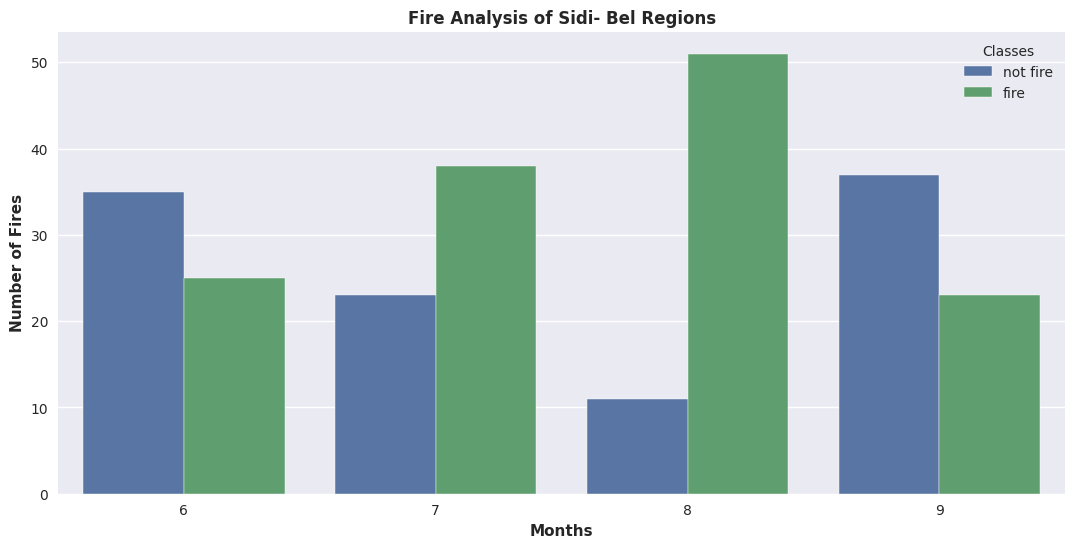

In [236]:
## Monthly Fire Analysis
dftemp=df.loc[df['Region']==1]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data=df)
plt.ylabel('Number of Fires',weight='bold')
plt.xlabel('Months',weight='bold')
plt.title("Fire Analysis of Sidi- Bel Regions",weight='bold')

Text(0.5, 1.0, 'Fire Analysis of Sidi- Bel Regions')

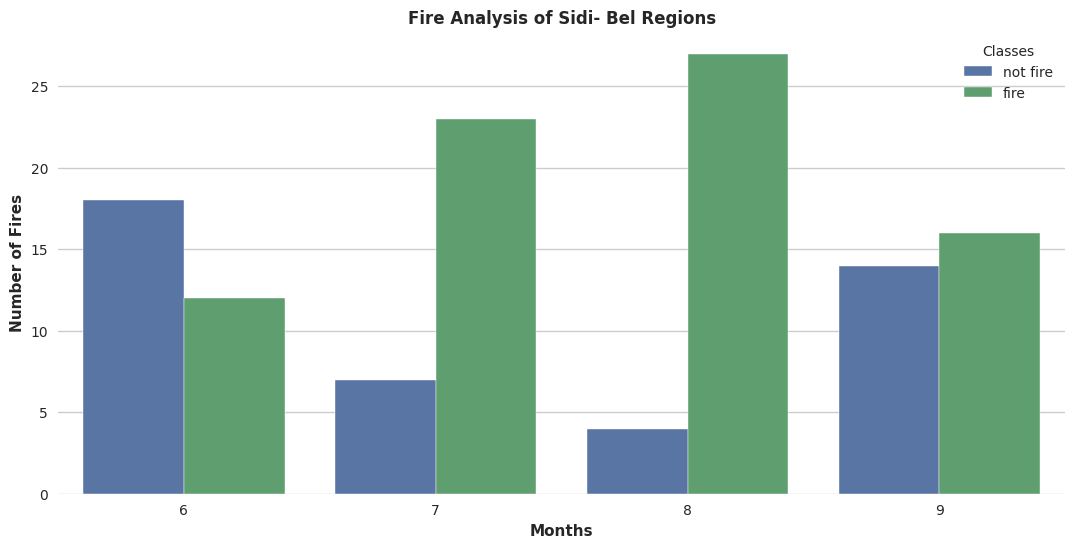

In [237]:
## Monthly Fire Analysis
dftemp=df.loc[df['Region']==1]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data=dftemp)
plt.ylabel('Number of Fires',weight='bold')
plt.xlabel('Months',weight='bold')
plt.title("Fire Analysis of Sidi- Bel Regions",weight='bold')

### Monthly Fire Count for Bejaia Region
Filter the data for Region 0 (Bejaia) and plot a count of fire vs. not-fire occurrences per month to compare seasonal trends with the other region.

**Detailed explanation of the Bejaia monthly fire analysis cell:**

```python
## Monthly Fire Analysis
dftemp=df.loc[df['Region']==0]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data=df)
plt.ylabel('Number of Fires',weight='bold')
plt.xlabel('Months',weight='bold')
plt.title("Fire Analysis of Brjaia Regions",weight='bold')
```

This cell mirrors the previous Sidi-Bel Abbes analysis, but targeting the other region:

1. **`## Monthly Fire Analysis`** — Comment marking the section; not executed.

2. **`dftemp=df.loc[df['Region']==0]`** — Filters `df` to only rows where `Region` equals `0`, which corresponds to the **Bejaia** region (per the earlier region-labeling step; `Region=1` is Sidi-Bel Abbes). The result is stored in `dftemp`.

3. **`plt.subplots(figsize=(13,6))`** — Creates a new blank matplotlib figure/axes sized 13×6 inches for the plot to draw onto.

4. **`sns.set_style('whitegrid')`** — Sets the seaborn theme to a white background with light gridlines for readability.

5. **`sns.countplot(x='month',hue='Classes',data=df)`** — Draws a bar chart of row counts per month (`x='month'`), split into `fire`/`not fire` sub-bars by color (`hue='Classes'`), pulling data from `data=df`.

6. **`plt.ylabel(...)`, `plt.xlabel(...)`, `plt.title(...)`** — Sets bold axis labels ("Number of Fires", "Months") and the chart title ("Fire Analysis of Brjaia Regions" — note the typo, should read "Bejaia").

**⚠️ Same bug as the Sidi-Bel Abbes cell:** `dftemp` is filtered to `Region==0` (Bejaia only) but is never used — `countplot` plots `data=df`, the full combined dataset, instead of `data=dftemp`. The intended line was almost certainly:
```python
sns.countplot(x='month',hue='Classes',data=dftemp)
```
As a result, this chart is not actually specific to the Bejaia region — it renders the exact same combined-region data as the "Sidi-Bel Abbes" chart above it, so both plots come out identical despite having different titles. Fixing both cells to use `data=dftemp` (with each cell's own `dftemp`) would make them show two genuinely different, region-specific breakdowns.

Text(0.5, 1.0, 'Fire Analysis of Brjaia Regions')

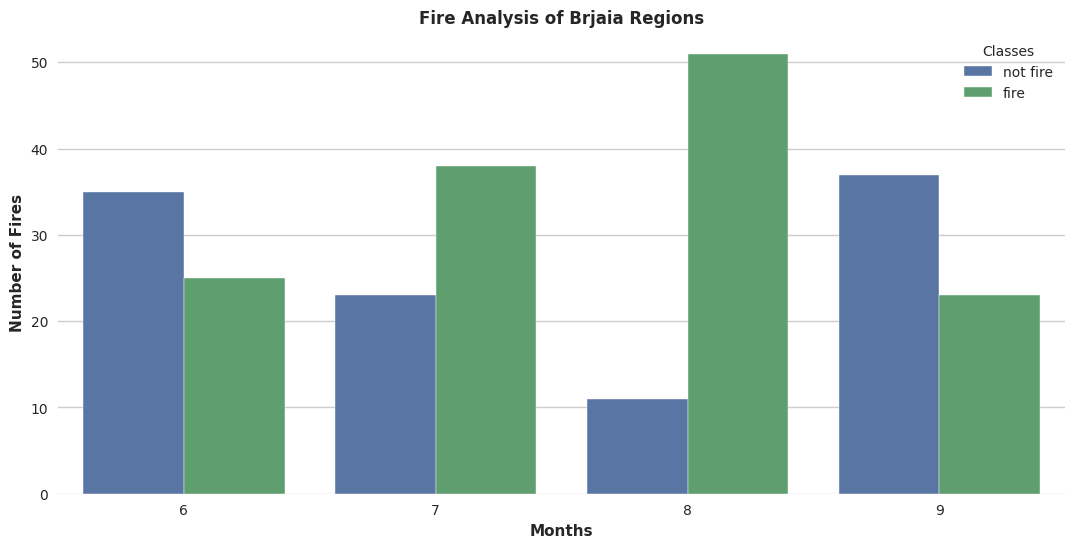

In [238]:
## Monthly Fire Analysis
dftemp=df.loc[df['Region']==0]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data=df)
plt.ylabel('Number of Fires',weight='bold')
plt.xlabel('Months',weight='bold')
plt.title("Fire Analysis of Brjaia Regions",weight='bold')

Text(0.5, 1.0, 'Fire Analysis of Brjaia Regions')

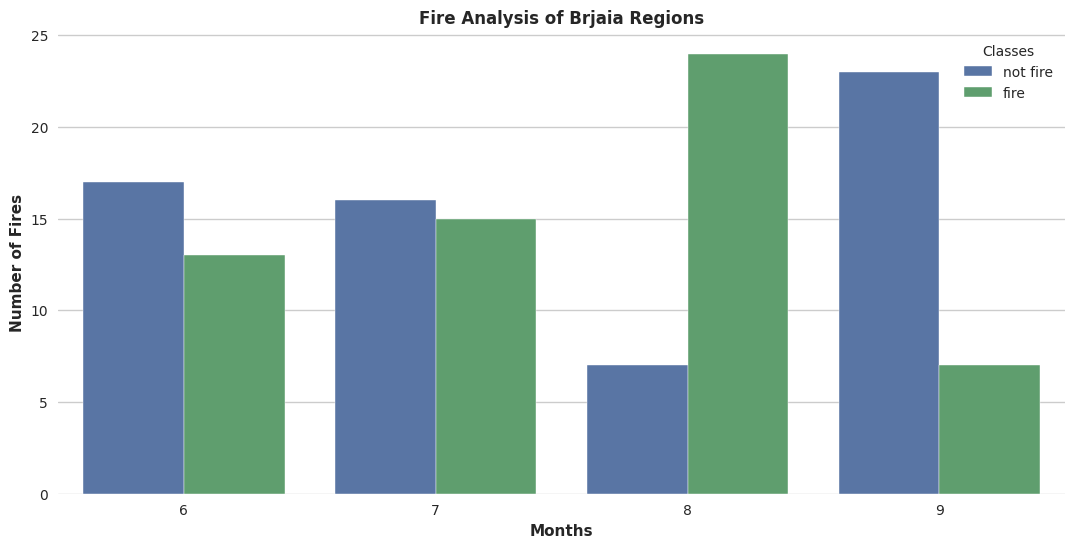

In [239]:
## Monthly Fire Analysis
dftemp=df.loc[df['Region']==0]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data=dftemp)
plt.ylabel('Number of Fires',weight='bold')
plt.xlabel('Months',weight='bold')
plt.title("Fire Analysis of Brjaia Regions",weight='bold')

Its observed that August and July had the most number of forest fires for both regions. And from the above plot of months, we can understand few things

Most of the fires happened in August and very high Fires happened in only 3 months - June, July and August.

Less Fires was on September

PART TWO

# Project Workflow: Model Training (Ridge, Lasso & ElasticNet Regression)

**1. Data Loading & Prep**
- Load cleaned dataset (`Algerian_forest_fires_cleaned_dataset.csv`)
- Drop irrelevant date columns (`day`, `month`, `year`)
- Encode the target `Classes` column (categorical → numeric)

**2. Feature/Target Split**
- Separate into `X` (features) and `y` (target)
- `train_test_split` → `X_train`, `X_test`, `y_train`, `y_test`

**3. Multicollinearity Check**
- Compute correlation matrix on `X_train`, visualize with a heatmap
- Custom `correlation()` function flags features with pairwise correlation > 0.85
- Drop those flagged features from `X_train`/`X_test`

**4. Feature Scaling**
- `StandardScaler` → `X_train_scaled`, `X_test_scaled`
- Box plots comparing feature distributions before/after scaling

**5. Model Training & Evaluation** — same pattern for each: fit → predict on test set → MAE + R² → scatter plot of actual vs. predicted

| Model | Plain fit | Cross-validated tuning |
|---|---|---|
| **Linear Regression** | `LinearRegression().fit(...)` → eval | — (baseline) |
| **Lasso** | `Lasso().fit(...)` → eval | `LassoCV(cv=5)` → inspect `.alpha_`, `.alphas_`, `.mse_path_` → eval |
| **Ridge** | `Ridge().fit(...)` → eval | `RidgeCV(cv=5)` → inspect `.get_params()` → eval |
| **ElasticNet** | `ElasticNet().fit(...)` → eval | `ElasticNetCV(cv=5)` → inspect `.alphas_` → eval |

**6. Final Model Comparison**
- Build `comparison_df`: MAE + R² for all 7 fitted models (`linreg`, `lasso`, `lassocv`, `ridge`, `ridgecv`, `elastic`, `elasticcv`) side by side, sorted by R² descending
- Bar chart (`sns.barplot`) visualizing R² score per model for at-a-glance comparison

---


### Import Required Libraries
Import `pandas`, `numpy`, `matplotlib.pyplot`, and `seaborn` for data handling and visualization, and enable inline plotting with `%matplotlib inline`.

In [240]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Load the Cleaned Dataset
Read the previously cleaned `Algerian_forest_fires_cleaned_dataset.csv` file (produced in the Ridge, Lasso Regression notebook) into a DataFrame.

In [241]:
df=pd.read_csv('Algerian_forest_fires_cleaned_dataset.csv')

### Preview the Dataset
Display the first 5 rows to confirm the cleaned dataset loaded correctly.

In [242]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


### List Column Names
Print all column names to plan which features to drop or keep for modeling.

In [243]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

### Drop Date-Related Columns
Remove the `day`, `month`, and `year` columns in place, since they are not useful predictive features for the regression models.

In [244]:
##drop month,day and yyear
df.drop(['day','month','year'],axis=1,inplace=True)

### Preview Dataset After Dropping Date Columns
Display the first 5 rows to confirm the date columns were removed.

In [245]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


### Check Class Distribution
Count the occurrences of each category (`fire`/`not fire`) in the `Classes` column before encoding.

In [246]:
df['Classes'].value_counts()

,count
Classes,
fire,131
not fire,101
fire,4
fire,2
not fire,2
not fire,1
not fire,1
not fire,1


### Encode the Classes Column
Convert the categorical `Classes` column into binary values: 0 for `not fire` and 1 for `fire`, so it can be used as a numeric feature.

In [247]:
## Encoding
df['Classes']=np.where(df['Classes'].str.contains("not fire"),0,1)

### Preview the End of the Dataset
Display the last 5 rows to confirm the encoding was applied correctly across the dataset.

In [248]:
df.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1
242,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0,1


### Recheck Class Distribution After Encoding
Count the encoded values (0/1) to confirm they match the original category counts.

In [249]:
df['Classes'].value_counts()

,count
Classes,
1,137
0,106


### Define Independent and Dependent Variables
Separate the data into `X` (all columns except `FWI`) and the target variable `y` (`FWI`), since the Fire Weather Index is the value the regression models will predict.

In [250]:
## Independent And dependent features
X=df.drop('FWI',axis=1)
y=df['FWI']

In [284]:
y

,FWI
0,0.5
1,0.4
2,0.1
3,0.0
4,0.5
...,...
238,6.5
239,0.0
240,0.2
241,0.7


In [287]:
y= df.iloc[:,-3]

In [288]:
y

,FWI
0,0.5
1,0.4
2,0.1
3,0.0
4,0.5
...,...
238,6.5
239,0.0
240,0.2
241,0.7


### Preview the Feature Matrix
Display the first 5 rows of `X` to confirm the independent variables are set up correctly.

In [251]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


### Preview the Target Variable
Display the `y` series (FWI values) that the models will be trained to predict.

In [252]:
y

,FWI
0,0.5
1,0.4
2,0.1
3,0.0
4,0.5
...,...
238,6.5
239,0.0
240,0.2
241,0.7


### Split Data into Training and Test Sets
Use `train_test_split` from scikit-learn to divide the data into 75% training and 25% testing sets, with a fixed `random_state` for reproducibility.

In [253]:
#Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

### Check Train/Test Split Shapes
Print the shapes of `X_train` and `X_test` to confirm the split proportions.

In [254]:
X_train.shape,X_test.shape

((182, 11), (61, 11))

### Compute Correlation Matrix on Training Features
Calculate pairwise correlations between the training features to check for multicollinearity.

In [255]:
## Feature Selection based on correlaltion
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


### Visualize Multicollinearity with a Heatmap
Plot an annotated heatmap of the training feature correlations to visually identify highly correlated feature pairs.

<Axes: >

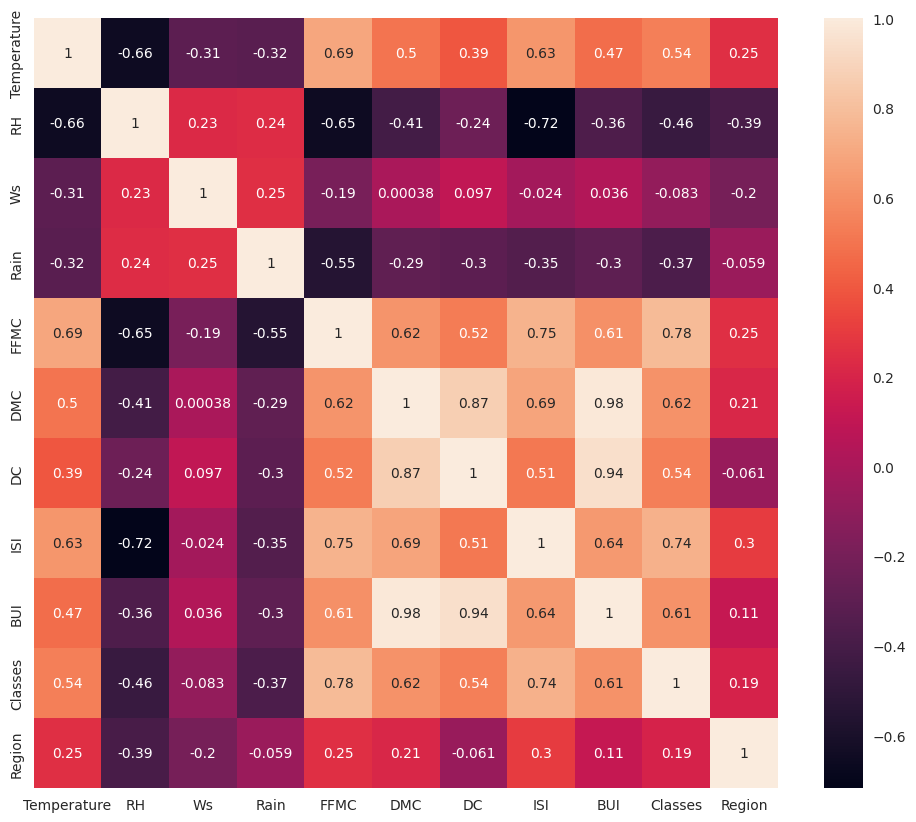

In [256]:
## Check for multicollinearity
plt.figure(figsize=(12,10))
corr=X_train.corr()
sns.heatmap(corr,annot=True)


### Define a Function to Find Highly Correlated Features
Create a helper function `correlation` that scans a correlation matrix and returns the set of column names whose pairwise correlation exceeds a given threshold.

### Explanation: `correlation()` function

This function identifies columns that are **highly correlated** with another column (above a given `threshold`), so they can be dropped before model training. Removing highly correlated (multicollinear) features is especially important for Ridge/Lasso/Elastic Net, since multicollinearity destabilizes linear model coefficients.

```python
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr
```

**Line by line**

1. `col_corr = set()` — empty set to collect names of columns flagged as highly correlated. A set avoids duplicate names even if a column is flagged more than once.
2. `corr_matrix = dataset.corr()` — computes the pairwise Pearson correlation between every numeric column. Result is an N×N matrix where cell `[i, j]` is the correlation between column `i` and column `j`. Values range from -1 to 1; the diagonal is always 1.
3. `for i in range(len(corr_matrix.columns))` — loops over every column index.
4. `for j in range(i)` — inner loop only covers indices `0` to `i-1`, i.e. the **lower triangle** of the matrix (excluding the diagonal). Since the matrix is symmetric (`corr[i,j] == corr[j,i]`) and the diagonal is trivially 1, this avoids redundant/self comparisons.
5. `if abs(corr_matrix.iloc[i, j]) > threshold:` — uses `abs()` so both strong positive (near 1) and strong negative (near -1) correlations are caught.
6. `colname = corr_matrix.columns[i]` — grabs the name of column `i` (not `j`). Design choice: whenever a highly correlated pair is found, only the later-encountered column (`i`) gets flagged for removal; the earlier one (`j`) is kept.
7. `col_corr.add(colname)` — adds that column name to the result set.
8. `return col_corr` — returns the set of column names recommended for removal.

**Caveat**: because only the `i`-th column is ever added (and `j` is always kept), which column survives from a correlated pair depends purely on column order in the DataFrame — not on which one is more informative (e.g. more correlated with the target). It also doesn't prevent chains: if A–B and B–C are both correlated but A–C isn't, both B and C can end up flagged, potentially dropping more than strictly necessary.

---

### Worked example

```python
import pandas as pd

data = {
    'A': [1, 2, 3, 4, 5],
    'B': [2, 4, 6, 8, 11],      # tracks A closely
    'C': [5, 3, 4, 2, 1],       # roughly unrelated to A/B
    'D': [10, 20, 29, 41, 50],  # tracks A closely too
}
df = pd.DataFrame(data)
```

**Step 1 — correlation matrix** (`df.corr()`, illustrative values):

```
      A       B       C       D
A   1.00    0.95    0.10    0.85
B   0.95    1.00    0.05    0.20
C   0.10    0.05    1.00    0.90
D   0.85    0.20    0.90    1.00
```

With `threshold = 0.8`:

| i | j | pair | corr | `abs > 0.8`? | action |
|---|---|------|------|--------------|--------|
| 0 (A) | — | — | — | — | inner loop empty |
| 1 (B) | 0 (A) | (B, A) | 0.95 | ✅ | add `B` |
| 2 (C) | 0 (A) | (C, A) | 0.10 | ❌ | skip |
| 2 (C) | 1 (B) | (C, B) | 0.05 | ❌ | skip |
| 3 (D) | 0 (A) | (D, A) | 0.85 | ✅ | add `D` |
| 3 (D) | 1 (B) | (D, B) | 0.20 | ❌ | skip |
| 3 (D) | 2 (C) | (D, C) | 0.90 | ✅ | add `D` (already present) |

**Step 2 — result**

```python
col_corr = correlation(df, 0.8)
# {'B', 'D'}

df_reduced = df.drop(columns=col_corr)
# df_reduced keeps only columns A and C
```

`B` and `D` are dropped because each exceeded the 0.8 threshold with an earlier column (`A`, or `C` in D's case) — leaving `A` and `C`, the earliest-appearing, least-redundant columns.


### Deep Dive: the nested loop `for i in range(...): for j in range(i)`

```python
for i in range(len(corr_matrix.columns)):
    for j in range(i):
```

**Outer loop — `for i in range(len(corr_matrix.columns))`**

`corr_matrix` is a square matrix (N columns × N rows, since it's a correlation matrix). `len(corr_matrix.columns)` gives `N`, the number of columns. So `i` walks through every column index: `0, 1, 2, ..., N-1`.

**Inner loop — `for j in range(i)`**

This is the key part. `range(i)` produces `0, 1, ..., i-1` — **not** including `i` itself. So as `i` grows, `j` gets more values to iterate over:

| `i` | `range(i)` → values of `j` |
|---|---|
| 0 | *(empty — no iterations)* |
| 1 | `0` |
| 2 | `0, 1` |
| 3 | `0, 1, 2` |
| 4 | `0, 1, 2, 3` |

So for a 4-column matrix (indices 0–3), the `(i, j)` pairs visited are:

```
i=1: j=0                → (1,0)
i=2: j=0,1               → (2,0), (2,1)
i=3: j=0,1,2             → (3,0), (3,1), (3,2)
```

That's 6 pairs total out of the 16 cells in a 4×4 matrix.

**Why this pattern — visualizing the matrix as a grid:**

```
        j=0    j=1    j=2    j=3
i=0   [ 1.00 ]  .      .      .
i=1   [ 0.95   1.00 ]  .      .
i=2   [ 0.10   0.05   1.00 ]  .
i=3   [ 0.85   0.20   0.90   1.00 ]
```

The `(i, j)` pairs visited (marked with brackets `[ ]` above) form exactly the **lower triangle**, strictly below the diagonal. Three things are deliberately skipped:

1. **The diagonal** (`i == j`) — always `1.00` since every column is perfectly correlated with itself. Checking it would be pointless.
2. **The upper triangle** (`j > i`) — skipped because a correlation matrix is always **symmetric**: `corr_matrix.iloc[i, j] == corr_matrix.iloc[j, i]`. Checking `(2,3)` would just repeat information already seen at `(3,2)`.
3. Because `j` only ranges up to `i - 1`, you never accidentally compare `i` with itself or revisit a pair from the other side.

**Net effect**: instead of checking all N² cells (16 for a 4×4 matrix), this only checks `N(N-1)/2` cells (6 for N=4) — exactly once per unique pair of distinct columns. It's the standard trick for iterating over "all unique pairs" without duplicates when working with a symmetric matrix.


In [257]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

### Identify Features Above the Correlation Threshold
Apply the `correlation` function with a threshold of 0.85 (chosen based on domain expertise) to find features that are highly correlated with others.

In [258]:
## threshold--Domain expertise
corr_features=correlation(X_train,0.85)

### Why BUI and DC are multicollinear with DMC

**Root cause — it's built into the FWI formula, not a coincidence in the data:**

The Canadian Forest Fire Weather Index (FWI) system defines these as:
- **DMC** (Duff Moisture Code) — moisture in loosely compacted organic layers (medium-term drying)
- **DC** (Drought Code) — moisture in deep, compact organic layers (long-term drying)
- **BUI** (Buildup Index) — a weighted combination of DMC and DC, representing total fuel available to burn:

```
if DMC <= 0.4 * DC:
    BUI = 0.8 * DMC * DC / (DMC + 0.4 * DC)
else:
    BUI = DMC - (1 - 0.8*DC/(DMC + 0.4*DC)) * (0.92 + (0.0114*DMC)**1.7)
```

Because BUI is mathematically derived *from* DMC and DC, it is forced to correlate highly with both.

**What the correlation matrix showed:**
- `DMC` vs `BUI` → **0.98** (BUI is weighted more heavily toward DMC)
- `DMC` vs `DC` → **0.87**
- `DC` vs `BUI` → **0.94**

**Why `col_corr` ended up as `{'BUI', 'DC'}` and not something else:**

In `correlation(dataset, threshold)`, columns are scanned left to right (`DMC` appears before `DC`, which appears before `BUI`). For each column `i`, the inner loop only checks against earlier columns `j < i`:
- When `i = DC`: compared against `DMC` → 0.87 > 0.85 → **DC flagged**
- When `i = BUI`: compared against `DMC` first → 0.98 > 0.85 → **BUI flagged** (already exceeds threshold here, so it doesn't matter that BUI vs DC is also high)

So **DMC is the anchor column that both DC and BUI get dropped against** — BUI wasn't dropped because of DC, it was dropped because of its own (even stronger) correlation with DMC. DMC survives simply because it's the earliest of the three in column order, not because it's inherently "more informative."

**Analogy — student exam scores:**
- `Assignment_Score` (≈ DMC)
- `Attendance_Score` (≈ DC)
- `Final_Grade = 0.7*Assignment_Score + 0.3*Attendance_Score` (≈ BUI)

`Final_Grade` is a formula built from the other two, so it necessarily correlates highly with both — more strongly with `Assignment_Score` since it carries more weight. Feeding a model `Assignment_Score`, `Attendance_Score`, **and** `Final_Grade` together just repeats the same signal three times and destabilizes coefficients (multicollinearity) — exactly the problem `correlation()` + dropping `{'BUI', 'DC'}` avoids before fitting Ridge/Lasso/ElasticNet.

In [259]:
corr_features

{'BUI', 'DC'}

### Remove Highly Correlated Features
Drop the identified multicollinear features from both `X_train` and `X_test`, then print the resulting shapes to confirm the reduction.

In [260]:
## drop features when correlation is more than 0.85
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)
X_train.shape,X_test.shape

((182, 9), (61, 9))

## Feature Scaling Or Standardization

### Apply Feature Scaling (Standardization)
Use `StandardScaler` to standardize the training features (mean 0, variance 1) and apply the same transformation to the test set, since Ridge, Lasso, and ElasticNet are sensitive to feature scale.

In [261]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

### Why `scaler.pkl` Must Be Saved and Deployed Alongside the Model

**Why scaling is needed at all:**
Ridge, Lasso, and ElasticNet all add a penalty term on the *magnitude* of coefficients (L2, L1, or both). If features are left on their raw, mismatched scales (e.g. `DC` ranges 7-220 while `Rain` ranges 0-1), the penalty unfairly shrinks coefficients on larger-scale features just because of units, not actual importance. `StandardScaler` puts every feature on mean-0/variance-1 footing so the penalty applies fairly across all of them.

**Fit only on `X_train`, transform `X_test` (no leakage):**
```python
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learns mean_/scale_ from train only
X_test_scaled  = scaler.transform(X_test)        # reuses train's mean_/scale_, no refitting
```
If the scaler were fit on `X_test` (or on train+test combined), statistics from the "unseen" test data would leak into training — inflating test R?/MAE and giving an overly optimistic sense of how the model performs on truly new data.

**Why both `scaler.pkl` and the model's `.pkl` need to be saved together:**
The model (`ridgecv`) was trained on *scaled* features, so its coefficients are only meaningful in that scaled space. Deploying the model without the exact same fitted scaler means any new input would need scaling from scratch — but a single new sample has no valid mean/variance of its own, and refitting would silently break the correspondence between input and what the model learned.

**Deployment / inference flow:**
```python
import pickle, pandas as pd

scaler = pickle.load(open('scaler.pkl', 'rb'))
model  = pickle.load(open('ridgecv.pkl', 'rb'))

# Must match X_train's final 9 columns, same order, after dropping
# day/month/year and corr_features ({'BUI', 'DC'}):
# Temperature, RH, Ws, Rain, FFMC, DMC, ISI, Classes, Region
new_reading = pd.DataFrame([{
    "Temperature": 32, "RH": 45, "Ws": 15, "Rain": 0,
    "FFMC": 88.2, "DMC": 30.1, "ISI": 6.5,
    "Classes": 1, "Region": 0
}])

new_scaled = scaler.transform(new_reading)   # transform ONLY, never fit_transform here
prediction = model.predict(new_scaled)
```

Key rules that make this correct:
1. **`scaler.transform(...)`, never `fit_transform(...)`, on new/inference data** — reuses the frozen train-time `mean_`/`scale_`, exactly like `X_test` was handled during evaluation.
2. **Column order and count must match training exactly** — the scaled array has no column names, so any mismatch (wrong order, forgetting to drop `BUI`/`DC`) silently applies the wrong statistics to the wrong feature instead of erroring.
3. **Raw input must pass through the same upstream cleaning** (type casts, encoding `Classes`/`Region`, dropping `day`/`month`/`year`) before reaching `scaler.transform`.

**More robust alternative:** wrap both into one `sklearn.pipeline.Pipeline([('scaler', scaler), ('model', ridgecv)])` and pickle that single object instead of two separate files — deployment then becomes one call, `pipeline.predict(new_reading)`, and a mismatched scaler/model pairing becomes structurally impossible.

### Preview Scaled Training Data
Display the standardized training feature array to confirm the scaling was applied.

In [262]:
X_train_scaled

array([[-0.84284248,  0.78307967,  1.29972026, ..., -0.62963326,
        -1.10431526, -0.98907071],
       [-0.30175842,  0.64950844, -0.59874754, ..., -0.93058524,
        -1.10431526,  1.01105006],
       [ 2.13311985, -2.08870172, -0.21905398, ...,  2.7271388 ,
         0.90553851,  1.01105006],
       ...,
       [-1.9250106 ,  0.9166509 ,  0.54033314, ..., -1.06948615,
        -1.10431526, -0.98907071],
       [ 0.50986767, -0.21870454,  0.16063958, ...,  0.5973248 ,
         0.90553851,  1.01105006],
       [-0.57230045,  0.98343651,  2.05910739, ..., -0.86113478,
        -1.10431526, -0.98907071]])

## Box Plots To understand Effect Of Standard Scaler

### Compare Feature Distributions Before and After Scaling
Plot side-by-side boxplots of the training features before and after standardization to visualize the effect of `StandardScaler`.

Text(0.5, 1.0, 'X_train After Scaling')

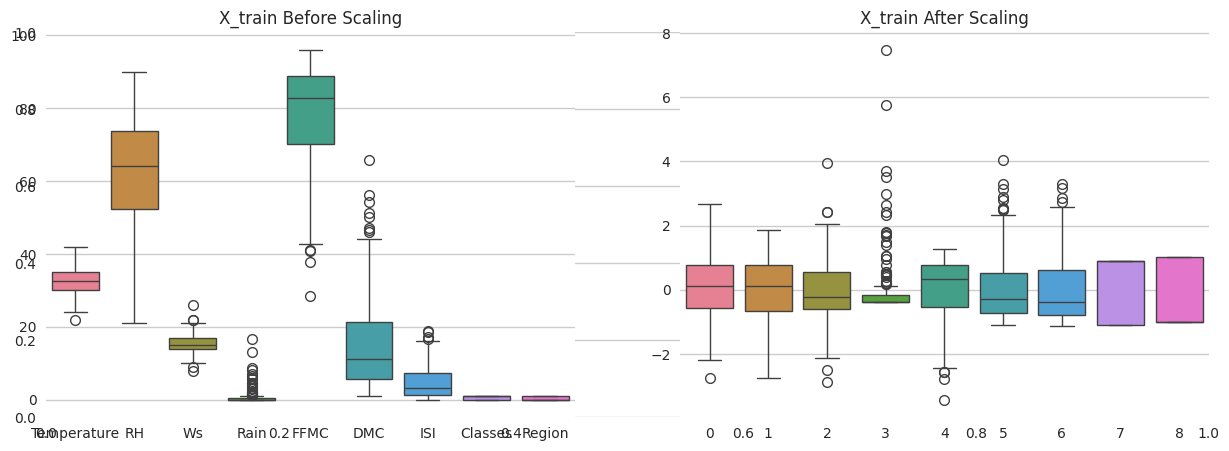

In [263]:
plt.subplots(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train)
plt.title('X_train Before Scaling')
plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scaled)
plt.title('X_train After Scaling')

## Linear Regression Model

### Train and Evaluate a Baseline Linear Regression Model
Fit an ordinary `LinearRegression` model on the scaled training data, predict on the test set, and evaluate performance using Mean Absolute Error (MAE) and R² score, followed by a scatter plot of actual vs. predicted values.

Mean absolute error 0.5468236465249986
R2 Score 0.9847657384266951


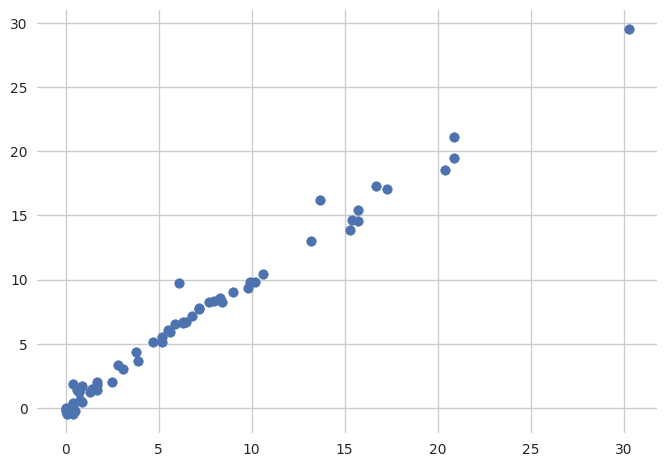

In [264]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
linreg=LinearRegression()
linreg.fit(X_train_scaled,y_train)
y_pred=linreg.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

## Lasso Regression

### Train and Evaluate a Lasso Regression Model
Fit a `Lasso` regression model (L1 regularization) with default alpha on the scaled training data, then evaluate it with MAE and R² score and visualize predictions against actual values.

Mean absolute error 1.133175994914409
R2 Score 0.9492020263112388


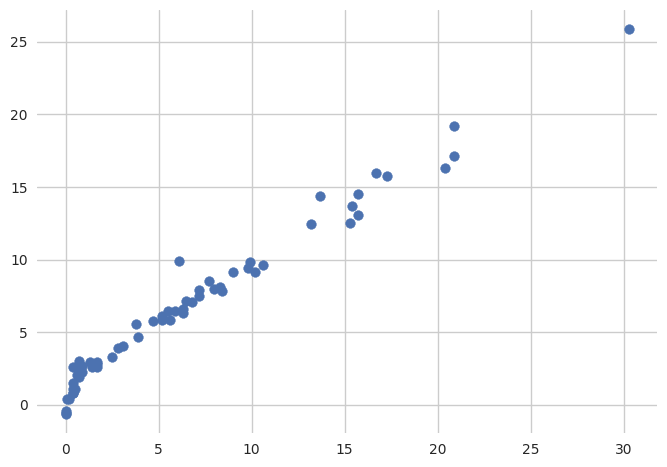

In [265]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
lasso=Lasso()
lasso.fit(X_train_scaled,y_train)
y_pred=lasso.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

### Cross Validation Lasso

### Tune Lasso's Alpha with Cross-Validation
Use `LassoCV` with 5-fold cross-validation to automatically find the best regularization strength (alpha) for the Lasso model.

### Explanation: `LassoCV` fitting

```python
from sklearn.linear_model import LassoCV
lassocv = LassoCV(cv=5)
lassocv.fit(X_train_scaled, y_train)
```

**Line 1 — the import**

`LassoCV` is scikit-learn's cross-validated version of Lasso Regression (L1-regularized linear regression). Plain `Lasso` requires manually picking the regularization strength `alpha`; `LassoCV` automatically searches over a range of `alpha` values using cross-validation and picks the best one.

**Line 2 — instantiating the model**

```python
lassocv = LassoCV(cv=5)
```

- `cv=5` uses **5-fold cross-validation** to evaluate each candidate `alpha`. The training data is split into 5 folds; for each candidate `alpha`, the model trains on 4 folds and validates on the 5th, rotating through all 5 folds, and averages the error.
- Since `alphas` wasn't specified explicitly, `LassoCV` auto-generates its own candidate list (default `n_alphas=100`, log-spaced along a regularization path derived from the data — computed from `alpha_max`, the smallest alpha that would zero out all coefficients).

**Line 3 — fitting**

```python
lassocv.fit(X_train_scaled, y_train)
```

1. For **each candidate alpha** (up to 100 by default), runs 5-fold cross-validation: fit Lasso on 4 folds, measure MSE on the held-out fold, repeat for all 5 folds, average the error.
2. Picks the `alpha` with the **lowest average cross-validated MSE**.
3. **Refits** a final Lasso model on the *entire* `X_train_scaled`/`y_train` using that best alpha.

Note `X_train_scaled` — Lasso (like Ridge) is sensitive to feature scale because the L1 penalty is applied uniformly across coefficients. Without scaling, the penalty would unfairly shrink some coefficients more than others just due to units, so features must be standardized (e.g. via `StandardScaler`) before fitting.

**Useful attributes after fitting**

- `lassocv.alpha_` — the best `alpha` chosen by cross-validation.
- `lassocv.coef_` — the final fitted coefficients (some may be exactly `0`, since Lasso's L1 penalty performs implicit feature selection by shrinking unimportant coefficients to zero).
- `lassocv.intercept_` — the fitted intercept.
- `lassocv.mse_path_` — MSE for every alpha × every fold, useful for plotting a validation curve.
- `lassocv.predict(X_test_scaled)` — generate predictions on new/test data.

**Why `LassoCV` over plain `Lasso`**: it removes the need to manually tune `alpha` via something like `GridSearchCV`, since the alpha search and cross-validation are built into one call — convenient specifically for Lasso/Ridge/ElasticNet where `alpha` is the key hyperparameter controlling regularization strength (how aggressively coefficients get shrunk/zeroed).


In [266]:
from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)
lassocv.fit(X_train_scaled,y_train)

LassoCV(cv=5)

### Inspect the Best Alpha Found
Print the optimal alpha value selected by `LassoCV` through cross-validation.

In [267]:
lassocv.alpha_

np.float64(0.05725391318234408)

### Inspect All Alpha Values Tried
Print the full range of alpha values that `LassoCV` evaluated during cross-validation.

In [268]:
lassocv.alphas_

array([7.05853002, 6.58280872, 6.13914944, 5.72539132, 5.33951911,
       4.97965339, 4.64404142, 4.33104857, 4.03915039, 3.76692517,
       3.51304702, 3.27627941, 3.05546914, 2.84954075, 2.65749124,
       2.47838523, 2.31135036, 2.15557308, 2.01029467, 1.87480753,
       1.74845178, 1.63061198, 1.52071419, 1.41822315, 1.32263965,
       1.23349817, 1.15036452, 1.0728338 , 1.00052839, 0.93309613,
       0.87020857, 0.81155943, 0.75686304, 0.705853  , 0.65828087,
       0.61391494, 0.57253913, 0.53395191, 0.49796534, 0.46440414,
       0.43310486, 0.40391504, 0.37669252, 0.3513047 , 0.32762794,
       0.30554691, 0.28495408, 0.26574912, 0.24783852, 0.23113504,
       0.21555731, 0.20102947, 0.18748075, 0.17484518, 0.1630612 ,
       0.15207142, 0.14182231, 0.13226397, 0.12334982, 0.11503645,
       0.10728338, 0.10005284, 0.09330961, 0.08702086, 0.08115594,
       0.0756863 , 0.0705853 , 0.06582809, 0.06139149, 0.05725391,
       0.05339519, 0.04979653, 0.04644041, 0.04331049, 0.04039

### Inspect the Cross-Validation MSE Path
Print the mean squared error for each alpha and each cross-validation fold, showing how error changes across the regularization path.

In [269]:
lassocv.mse_path_

array([[53.64536329, 65.39074075, 54.89628985, 77.90299066, 39.38236846],
       [46.99139716, 59.81506814, 49.29840831, 75.6645852 , 35.31758355],
       [41.14908917, 53.9178721 , 42.49594889, 68.35708298, 31.76996123],
       [36.05788169, 48.41773965, 36.66879347, 61.92819453, 28.67296816],
       [31.62067285, 42.76466229, 31.68391904, 56.26841266, 24.93183295],
       [27.75285367, 37.81922812, 27.42599138, 51.28216115, 21.56888645],
       [24.3807738 , 33.49107651, 23.7950306 , 45.25481907, 18.66094162],
       [21.44052804, 29.70161639, 20.70460191, 39.90418045, 16.14837778],
       [18.876308  , 26.38208059, 18.07969934, 35.23429953, 13.97821475],
       [16.63960395, 23.47341883, 15.85530749, 31.15712074, 12.10483403],
       [14.68819307, 20.92329068, 13.97555108, 27.59649208, 10.48862803],
       [12.98525144, 18.68636627, 12.39173305, 24.48611006,  9.09521221],
       [11.49893734, 16.72312788, 11.06186319, 21.7677198 ,  7.89445038],
       [10.2013182 , 14.9991189 ,  9.9

### Evaluate the Tuned Lasso Model
Use the cross-validated Lasso model to predict on the test set, visualize predictions with a scatter plot, and compute MAE and R² score.

Mean absolute error 0.619970115826343
R2 Score 0.9820946715928275


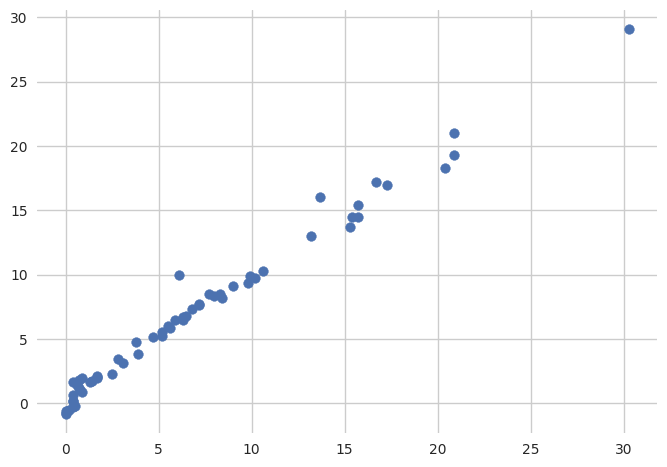

In [270]:
y_pred=lassocv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

## Ridge Regression model

### Train and Evaluate a Ridge Regression Model
Fit a `Ridge` regression model (L2 regularization) with default alpha on the scaled training data, then evaluate it with MAE and R² score and a scatter plot of predictions.

Mean absolute error 0.5642305340105692
R2 Score 0.9842993364555513


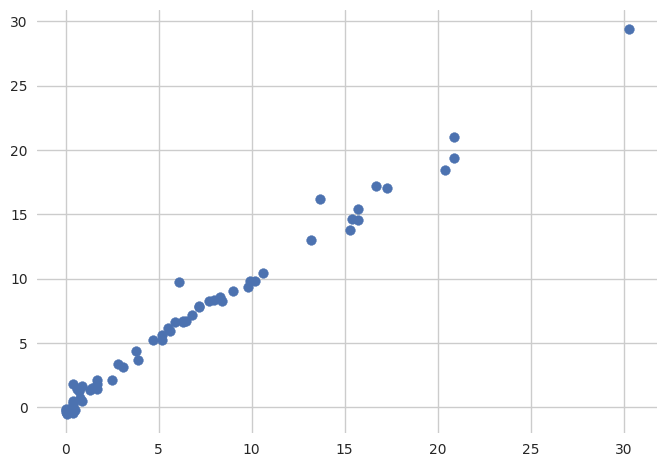

In [271]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
ridge=Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred=ridge.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

### Train and Evaluate a Ridge Regression Model
Fit a `Ridge` regression model (L2 regularization) with default alpha on the scaled training data, then evaluate it with MAE and R² score and a scatter plot of predictions.

Mean absolute error 0.5642305340105692
R2 Score 0.9842993364555513


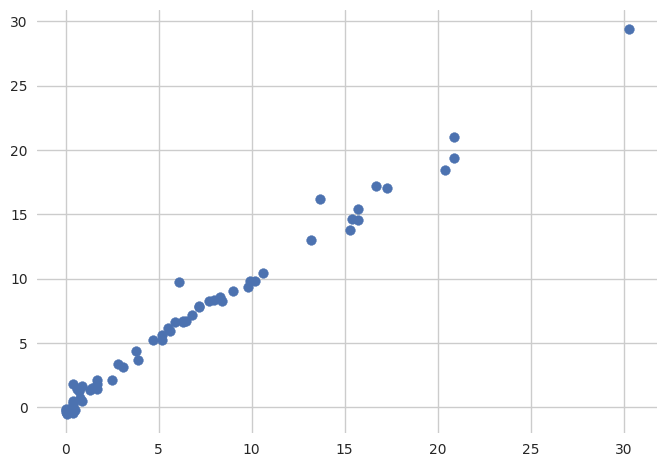

In [272]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
ridge=Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred=ridge.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

### Tune and Evaluate Ridge Regression with Cross-Validation
Use `RidgeCV` with 5-fold cross-validation to automatically select the best alpha, then predict on the test set and evaluate with MAE, R² score, and a scatter plot.

Mean absolute error 0.5642305340105692
R2 Score 0.9842993364555513


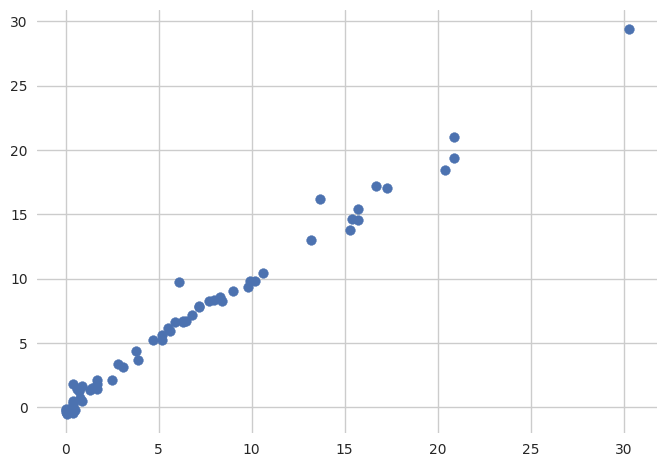

In [274]:
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV(cv=5)
ridgecv.fit(X_train_scaled,y_train)
y_pred=ridgecv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

### Inspect RidgeCV Model Parameters
Print all parameters used by the fitted `RidgeCV` model, including the selected alpha and cross-validation settings.

In [275]:
ridgecv.get_params()

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': 5,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_results': None,
 'store_cv_values': 'deprecated'}

## Elasticnet Regression

### Train and Evaluate an ElasticNet Regression Model
Fit an `ElasticNet` model (combining L1 and L2 regularization) with default parameters, then evaluate it with MAE, R² score, and a scatter plot of predictions.

Mean absolute error 1.8822353634896005
R2 Score 0.8753460589519703


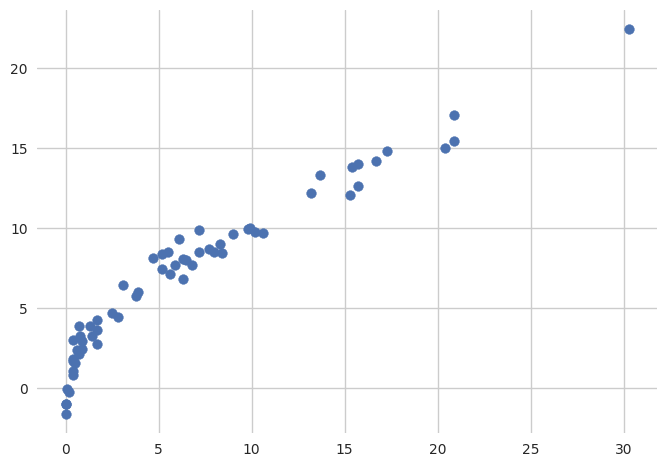

In [276]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
elastic=ElasticNet()
elastic.fit(X_train_scaled,y_train)
y_pred=elastic.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

### Tune and Evaluate ElasticNet with Cross-Validation
Use `ElasticNetCV` with 5-fold cross-validation to automatically find the best alpha and l1_ratio, then evaluate the tuned model with MAE, R² score, and a scatter plot.

Mean absolute error 0.6575946731430898
R2 Score 0.9814217587854941


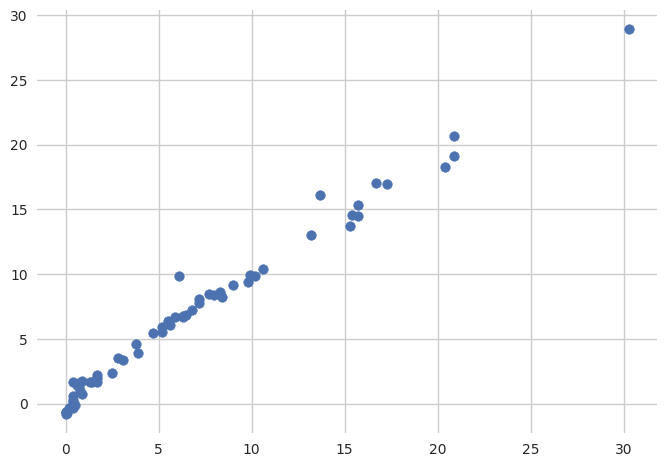

In [277]:
from sklearn.linear_model import ElasticNetCV
elasticcv=ElasticNetCV(cv=5)
elasticcv.fit(X_train_scaled,y_train)
y_pred=elasticcv.predict(X_test_scaled)
plt.scatter(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

### Inspect Alpha Values Tried by ElasticNetCV
Print the range of alpha values evaluated during ElasticNet's cross-validation.

In [278]:
elasticcv.alphas_

array([14.11706004, 13.16561744, 12.27829889, 11.45078264, 10.67903821,
        9.95930678,  9.28808283,  8.66209714,  8.07830078,  7.53385034,
        7.02609405,  6.55255882,  6.11093829,  5.6990815 ,  5.31498248,
        4.95677045,  4.62270071,  4.31114616,  4.02058933,  3.74961507,
        3.49690356,  3.26122397,  3.04142839,  2.83644629,  2.64527931,
        2.46699633,  2.30072904,  2.1456676 ,  2.00105679,  1.86619226,
        1.74041714,  1.62311885,  1.51372607,  1.411706  ,  1.31656174,
        1.22782989,  1.14507826,  1.06790382,  0.99593068,  0.92880828,
        0.86620971,  0.80783008,  0.75338503,  0.7026094 ,  0.65525588,
        0.61109383,  0.56990815,  0.53149825,  0.49567705,  0.46227007,
        0.43111462,  0.40205893,  0.37496151,  0.34969036,  0.3261224 ,
        0.30414284,  0.28364463,  0.26452793,  0.24669963,  0.2300729 ,
        0.21456676,  0.20010568,  0.18661923,  0.17404171,  0.16231189,
        0.15137261,  0.1411706 ,  0.13165617,  0.12278299,  0.11

extras - to check which feature was dropped


Why X_train.columns and not X_train_scaled: X_train_scaled is typically a plain NumPy array output from StandardScaler, so it has lost the column names. lassocv.coef_ is ordered the same way as the columns you passed into .fit(), so pairing it with the original X_train.columns (same order, pre-scaling) recovers the feature names.

Why == 0 works reliably here: Lasso's L1 penalty can drive coefficients to exactly zero (unlike Ridge's L2 penalty, which only shrinks them toward zero without ever reaching it). So an exact equality check is valid — no need for np.isclose().

For ElasticNetCV (which blends L1 and L2), the same approach works since it still carries an L1 component:

In [279]:
import pandas as pd

coef = pd.Series(lassocv.coef_, index=X_train.columns)

dropped_features = coef[coef == 0].index.tolist()
kept_features = coef[coef != 0].index.tolist()

print("Dropped features (coef = 0):", dropped_features)
print("Kept features:", kept_features)

# see the actual coefficient values, sorted by magnitude
coef.sort_values(key=abs, ascending=False)


Dropped features (coef = 0): ['Temperature', 'RH', 'Ws', 'Rain']
Kept features: ['FFMC', 'DMC', 'ISI', 'Classes', 'Region']


,0
ISI,4.799939
DMC,3.601773
FFMC,-0.400639
Region,-0.302277
Classes,0.164090
Temperature,-0.000000
Rain,0.000000
RH,-0.000000
Ws,0.000000


For ElasticNetCV (which blends L1 and L2), the same approach works since it still carries an L1 component:

In [280]:
coef_en = pd.Series(elasticcv.coef_, index=X_train.columns)
dropped_en = coef_en[coef_en == 0].index.tolist()


In [281]:
dropped_en

['Temperature', 'Rain']

## Prediction Comparison

### Explanation: Dictionary Comprehension

```python
{name: model.predict(X_test_scaled) for name, model in models.items()}
```

**Breaking it down:**

- **Syntax pattern**: `{key_expr: value_expr for item in iterable}` — curly braces `{ }` with a `key: value` pair before the `for`, which is what makes it a *dict* comprehension (as opposed to `[ ]` for a list comprehension, or `{ }` with no colon for a set comprehension).

- **`models.items()`** — iterates over the dictionary as `(key, value)` pairs. Since `models = {"Linear Regression": linreg, "Lasso": lasso, ...}`, each iteration gives one `(name, model)` pair, e.g. `("Linear Regression", linreg)`, then `("Lasso", lasso)`, and so on.

- **`for name, model in models.items()`** — unpacks each `(name, model)` tuple into two variables in one go.

- **`name: model.predict(X_test_scaled)`** — for every `(name, model)` pair, builds a new key-value entry: the key is the model's name (string), and the value is the array of predictions from calling `.predict()` on that model.

**Equivalent to writing this longer form:**

```python
result = {}
for name, model in models.items():
    result[name] = model.predict(X_test_scaled)
```

The comprehension does that same loop-and-build-a-dict pattern in one line.

**Then**, wrapping it in `pd.DataFrame({...})` takes the resulting dict — where each key becomes a column name and each value (a NumPy array of predictions) becomes that column's data — and turns it directly into a DataFrame, with one column per model.

**Note**: `y_test.values` assumes `y_test` is a pandas Series (from `train_test_split`). If it's already a NumPy array, use `y_test` directly instead.

In [291]:
result = {}
for name, model in models.items():
    result[name] = model.predict(X_test_scaled)
    print(result)

{'Linear Regression': array([ 8.22340505e+00,  7.75252922e+00, -2.54117416e-01,  4.35589319e+00,
        6.69135945e+00,  1.36202538e+00,  2.03864111e+00,  7.79328670e+00,
        1.72547890e+00,  3.33158516e+00,  4.13723043e-01,  9.75001593e+00,
        9.33180880e+00,  1.70522541e+01,  1.85133518e+01,  1.24250301e+00,
        1.85818589e+00, -2.19341618e-02,  7.18794479e+00,  3.06137615e+00,
        1.43702876e+00,  2.31135272e-01,  6.57677437e+00,  3.31761969e-01,
        2.10846121e+01,  5.11915298e+00,  5.93220317e+00,  9.80969813e+00,
       -6.46764212e-02,  9.81330986e+00,  6.64475980e+00, -4.53909646e-01,
        1.04015941e+01,  1.45820244e+01,  1.47807316e+00,  4.33773546e-01,
        2.04109845e+00,  6.08454570e+00, -4.65467631e-01, -3.05185642e-01,
        6.68439528e+00,  1.79727675e+00,  8.59237254e+00, -2.66715046e-01,
        1.54439592e+01,  8.32647113e+00,  8.25849719e+00,  1.42038134e+00,
        1.29740729e+01,  1.21912915e+00,  2.95190998e+01,  5.55199228e+00,
   

In [289]:
import pandas as pd

models = {
    "Linear Regression": linreg,
    "Lasso": lasso,
    "LassoCV": lassocv,
    "Ridge": ridge,
    "RidgeCV": ridgecv,
    "ElasticNet": elastic,
    "ElasticNetCV": elasticcv,
}

predictions_df = pd.DataFrame({
    name: model.predict(X_test_scaled) for name, model in models.items()
})
predictions_df["Actual"] = y_test.values  # or list(y_test) if it's already an array

predictions_df


,Linear Regression,Lasso,LassoCV,Ridge,RidgeCV,ElasticNet,ElasticNetCV,Actual
0,8.223405,7.845705,8.174906,8.236960,8.236960,8.440192,8.268963,8.4
1,7.752529,7.476035,7.683125,7.771335,7.771335,8.484167,7.804990,7.2
2,-0.254117,1.062802,-0.256765,-0.205764,-0.205764,1.583982,-0.103735,0.5
3,4.355893,5.571826,4.726434,4.386417,4.386417,5.747047,4.591000,3.8
4,6.691359,7.158853,6.787158,6.730149,6.730149,7.999250,6.887253,6.5
...,...,...,...,...,...,...,...,...
56,0.642051,2.358369,0.990564,0.704198,0.704198,3.237494,0.994937,0.8
57,9.017026,9.129159,9.087373,9.051078,9.051078,9.624464,9.164863,9.0
58,3.627332,4.684214,3.844560,3.676047,3.676047,5.980909,3.914480,3.9
59,14.617082,13.657325,14.439912,14.631870,14.631870,13.781952,14.577311,15.4


Model Comparison

### Compare All Models on the Test Set
Build a summary table of Mean Absolute Error (MAE) and R² score for every model trained above — baseline and cross-validated Linear Regression, Lasso, Ridge, and ElasticNet — sorted by R² to see which generalizes best on the held-out test set.

In [282]:
import pandas as pd

models = {
    "Linear Regression": linreg,
    "Lasso": lasso,
    "LassoCV": lassocv,
    "Ridge": ridge,
    "RidgeCV": ridgecv,
    "ElasticNet": elastic,
    "ElasticNetCV": elasticcv,
}

comparison = []
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    comparison.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "R2 Score": r2_score(y_test, y_pred)
    })

comparison_df = pd.DataFrame(comparison).sort_values("R2 Score", ascending=False).reset_index(drop=True)
comparison_df

,Model,MAE,R2 Score
0,Linear Regression,0.546824,0.984766
1,RidgeCV,0.564231,0.984299
2,Ridge,0.564231,0.984299
3,LassoCV,0.619970,0.982095
4,ElasticNetCV,0.657595,0.981422
5,Lasso,1.133176,0.949202
6,ElasticNet,1.882235,0.875346


### Visualize R² Score Comparison
Plot each model's R² score as a bar chart to visually compare performance at a glance.

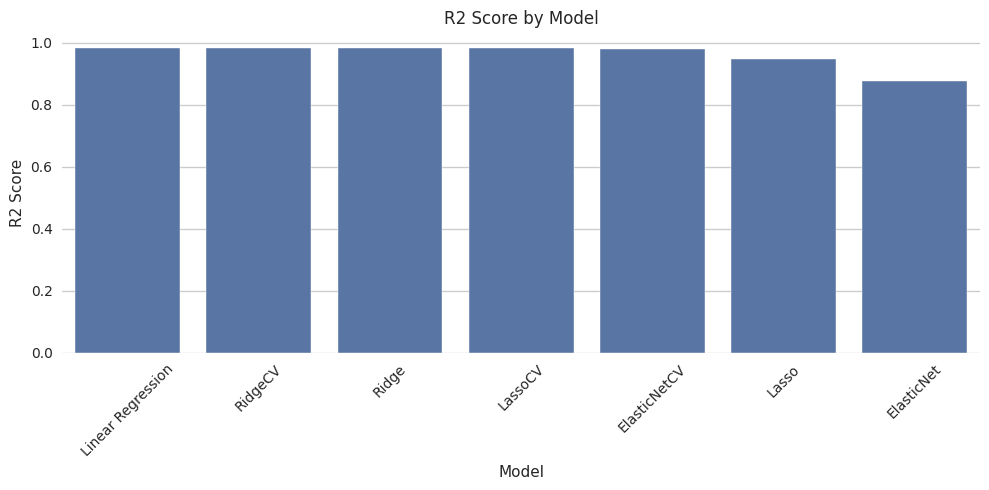

In [283]:
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x="Model", y="R2 Score")
plt.xticks(rotation=45)
plt.title("R2 Score by Model")
plt.tight_layout()
plt.show()

pickling the models, standard scaling 

Why scaler.pkl Must Be Saved and Deployed Alongside the Model
Why scaling is needed at all:
Ridge, Lasso, and ElasticNet all add a penalty on the magnitude of coefficients (L2, L1, or both). If features are left on raw, mismatched scales (e.g. DC ranges 7–220 while Rain ranges 0–1), the penalty unfairly shrinks coefficients on larger-scale features just because of units, not actual importance. StandardScaler puts every feature on mean-0/variance-1 footing so the penalty applies fairly across all of them.

Fit only on X_train, transform X_test (no leakage):


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learns mean_/scale_ from train only
X_test_scaled  = scaler.transform(X_test)        # reuses train's mean_/scale_, no refitting
If the scaler were fit on X_test (or train+test combined), statistics from the "unseen" test data would leak into training — inflating test R²/MAE and giving an overly optimistic sense of how the model performs on truly new data.

Why both scaler.pkl and the model's .pkl need to be saved together:
The model (ridgecv) was trained on scaled features, so its coefficients are only meaningful in that scaled space. Deploying the model without the exact same fitted scaler means any new input would need scaling from scratch — but a single new sample has no valid mean/variance of its own, and refitting would silently break the correspondence between input and what the model learned.


Key rules that make this correct:

scaler.transform(...), never fit_transform(...), on new/inference data — reuses the frozen train-time mean_/scale_, exactly like X_test was handled during evaluation.
Column order and count must match training exactly — the scaled array has no column names, so any mismatch (wrong order, forgetting to drop BUI/DC) silently applies the wrong statistics to the wrong feature instead of erroring.
Raw input must pass through the same upstream cleaning (type casts, encoding Classes/Region, dropping day/month/year) before reaching scaler.transform.

In [306]:
scaler

StandardScaler()

In [307]:
ridge

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [308]:
import pickle
pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump(ridge, open('ridge.pkl', 'wb'))